# UNDP CHALLENGE
## DEVELOPMENT EFFECTIVE ANALYSIS TRACK
### CROSS SECTOR SPILLOVER ANALYSIS - GENDER X CLIMATE

In [ ]:
import pandas as pd
import dask.dataframe as dd
import numpy as np
from tabs.utils import load_persist, load_or_build_parquet
import os, tempfile
from sklearn.cluster import KMeans
import seaborn as sns
import ace_tools_open as tools
import statsmodels.api as sm
import plotly.express as px
#import plotly.graph_objects as go
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import girvan_newman, asyn_lpa_communities
from sklearn.metrics import silhouette_score
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# 1. UNDP CRS DATASET

In [ ]:
#load the dataset using dask
def load_large_csv_chunked(filename, chunksize=50000):
    """Load large CSV in chunks and combine"""
    chunks = []

    # Read in chunks
    for chunk in pd.read_csv(filename, chunksize=chunksize, low_memory=False):
        chunks.append(chunk)

    # Combine all chunks
    df = pd.concat(chunks, ignore_index=True)
    return df

# Load using chunking method
print("Loading dataset using pandas chunking...")
df = load_large_csv_chunked('data/raw/crs/crs_data.csv')

Loading dataset using pandas chunking...


In [3]:
# Convert back to Dask  needed for large operations
df_dask = dd.from_pandas(df, npartitions=8)

## -----------------1.1 EXPLORATORY DATA ANALYSIS

In [4]:
print(f"Dataset loaded successfully with Dask")
print(f"Partitions: {df_dask.npartitions}")

# Get basic info about the dataset
print(f"Shape: {df_dask.shape[0].compute()} rows x {df.shape[1]} columns")

Dataset loaded successfully with Dask
Partitions: 8
Shape: 3843382 rows x 98 columns


In [5]:
print("\n2. DATASET OVERVIEW")
print("-" * 40)

# Basic information
print("Column Information:")
print(f"Total columns: {len(df_dask.columns)}")
print("\nColumn names and types:")

# Get sample for detailed inspection
df_sample = df_dask.head(1000)
print(df_sample.dtypes.to_string())

print(f"\nDataset time range:")
try:
    year_range = df_dask['Year'].agg(['min', 'max']).compute()
    print(f"From {year_range['min']} to {year_range['max']}")
except:
    print("Year column not found or accessible")



2. DATASET OVERVIEW
----------------------------------------
Column Information:
Total columns: 98

Column names and types:
Year                                    int64
DonorCode                               int64
DEDonorcode                   string[pyarrow]
DonorName                     string[pyarrow]
AgencyCode                            float64
AgencyName                    string[pyarrow]
CrsID                         string[pyarrow]
ProjectNumber                 string[pyarrow]
InitialReport                         float64
RecipientCode                 string[pyarrow]
DERecipientcode               string[pyarrow]
RecipientName                 string[pyarrow]
RegionCode                    string[pyarrow]
DERegioncode                  string[pyarrow]
RegionName                    string[pyarrow]
IncomegroupCode               string[pyarrow]
DEIncomegroupCode             string[pyarrow]
IncomegroupName               string[pyarrow]
FlowCode                      string[pyarrow]
F

In [6]:
# Compute the null fractions per column
null_frac = df_dask.isnull().mean().compute()

# maintain only columns with more than 60% data available
good_cols = null_frac[null_frac <= 0.6].index.tolist()

# Slice the Dask DataFrame by name
df_cleaned = df_dask[good_cols]

In [7]:
df_cleaned.head()

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,...,CompletionDate,LongDescription,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,CommitmentDate
0,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008560,6607565,8.0,139,...,2014-12-31,Provide criminal defense services to indigent ...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2014-08-15
1,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008562,6607567,1.0,625,...,2014-12-31,<NA>,1.0,1.0,2.0,0.0,0.0,0.0,0.0,2014-08-01
2,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008563,6607568,1.0,9998,...,2014-12-31,"Development of educated classes in society, pr...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014-01-01
3,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008564,6607570,8.0,9998,...,2014-12-31,Concentrated insight of the international part...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014-09-01
4,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008565,6607571,1.0,9998,...,2014-12-31,Professionalisation of young media professiona...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2014-07-01


In [8]:
df_cleaned.columns

Index(['Year', 'DonorCode', 'DEDonorcode', 'DonorName', 'AgencyCode',
       'AgencyName', 'CrsID', 'ProjectNumber', 'InitialReport',
       'RecipientCode', 'DERecipientcode', 'RecipientName', 'RegionCode',
       'DERegioncode', 'RegionName', 'IncomegroupCode', 'DEIncomegroupCode',
       'IncomegroupName', 'FlowCode', 'FlowName', 'Bi_Multi', 'Category',
       'Finance_T', 'Aid_T', 'USD_Commitment', 'USD_Disbursement',
       'USD_Received', 'USD_Commitment_Defl', 'USD_Disbursement_Defl',
       'USD_Received_Defl', 'USD_AmountUntied', 'USD_AmountTied',
       'USD_Amounttied_Defl', 'CurrencyCode', 'Commitment_National',
       'Disbursement_National', 'GrantEquiv', 'USD_GrantEquiv',
       'ShortDescription', 'ProjectTitle', 'PurposeCode', 'PurposeName',
       'SectorCode', 'SectorName', 'ChannelCode', 'ChannelName',
       'ChannelReportedName', 'ParentChannelCode', 'ExpectedStartDate',
       'CompletionDate', 'LongDescription', 'Gender', 'Environment', 'DIG',
       'RMNCH', 'B

In [9]:
#convert to pandas dataframe for easy aggregations
data1 = df_cleaned.compute()

In [10]:
#print shape
data1.shape

(3843382, 59)

In [11]:
data1['InitialReport'].unique()

array([8.0000e+00, 1.0000e+00, 3.0000e+00,        nan, 2.0000e+00,
       9.0000e+00, 2.7100e+02, 4.0999e+04, 4.1121e+04, 4.4001e+04,
       4.7109e+04, 4.1143e+04, 4.7086e+04, 4.6004e+04, 4.1114e+04,
       4.1122e+04, 4.1140e+04, 4.7999e+04, 4.4002e+04, 4.7097e+04,
       4.7078e+04, 4.7122e+04, 4.7107e+04, 4.1315e+04, 4.7040e+04,
       4.7044e+04, 4.1119e+04, 4.1126e+04, 4.7013e+04, 4.7027e+04,
       4.7132e+04, 4.7025e+04, 4.7096e+04, 4.7136e+04, 4.1107e+04,
       4.1146e+04, 4.1110e+04, 4.6005e+04, 4.1127e+04, 4.1304e+04,
       4.7045e+04, 4.7058e+04, 4.1999e+04, 4.7066e+04, 4.7003e+04,
       4.1111e+04, 4.7087e+04, 4.1148e+04, 4.1128e+04, 4.7131e+04,
       4.7080e+04, 4.1313e+04, 4.4004e+04, 4.1301e+04, 4.4999e+04,
       4.7083e+04, 4.1103e+04, 4.1302e+04, 4.1130e+04, 4.1303e+04,
       4.7015e+04, 4.1116e+04, 4.3001e+04, 4.7022e+04, 4.7093e+04,
       4.1310e+04, 4.7067e+04, 4.1101e+04, 4.1308e+04, 4.6002e+04,
       4.1123e+04, 4.2999e+04, 4.7011e+04, 4.7034e+04, 4.7029e

In [12]:
MARKER_COLS = ["Gender","ClimateMitigation","ClimateAdaptation",
               "Environment","DIG","RMNCH","Biodiversity"]
FORCED_STRING_COLS = [
    "CrsID","ProjectNumber","RecipientCode","RegionCode","DERegioncode",
]

In [13]:
# Convert development marker columns to nullable integer type
for c in MARKER_COLS:
    if c in data1.columns:
        data1[c] = pd.to_numeric(data1[c], errors="coerce").astype("Int8")
        
# Force mixed-type columns to string dtype
for c in FORCED_STRING_COLS:
    if c in data1.columns: 
        data1[c] = data1[c].astype("string")

In [14]:
#fill nulls for climateadaptation marker
data1['ClimateAdaptation'] = data1['ClimateAdaptation'].fillna(0).astype(int)

In [15]:
#check stats
data1.describe()

,Year,DonorCode,AgencyCode,InitialReport,Bi_Multi,Category,USD_Commitment,USD_Disbursement,USD_Received,USD_Received_Defl,...,Disbursement_National,GrantEquiv,ParentChannelCode,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation
count,3.843382e+06,3.843382e+06,3.732084e+06,3.837356e+06,3.098294e+06,3.054194e+06,2.986448e+06,3.538825e+06,1.783418e+06,2.012586e+06,...,2.798941e+06,1.682551e+06,2.865031e+06,2210308.0,1973656.0,1907408.0,1718902.0,1924333.0,1984098.0,3.843382e+06
mean,2.019100e+03,4.387820e+02,6.565809e+00,9.605519e+03,2.037987e+00,1.106204e+01,1.216115e+00,8.929169e-01,3.756295e-01,5.019910e+00,...,1.294648e+00,1.171609e+00,3.046108e+04,0.509158,0.396774,0.609319,0.158601,0.123817,0.127741,7.918313e-02
std,2.839242e+00,4.225499e+02,2.805170e+01,1.794117e+04,1.661670e+00,4.929908e+00,2.035237e+01,1.825082e+01,6.257179e+00,7.744974e+00,...,2.774808e+01,3.189358e+01,2.180508e+04,0.647891,0.685306,0.832564,0.479061,0.420926,0.418765,3.209292e-01
min,2.014000e+03,1.000000e+00,-9.861534e+01,1.000000e+00,1.000000e+00,0.000000e+00,-1.260762e+03,-6.970000e+02,0.000000e+00,0.000000e+00,...,-6.970000e+02,-6.970000e+02,1.000000e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
25%,2.017000e+03,1.200000e+01,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.568000e-03,6.372000e-03,1.200000e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
50%,2.019000e+03,3.020000e+02,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+01,2.000000e-03,1.368000e-02,0.000000e+00,3.250365e-01,...,2.832500e-02,4.548600e-02,2.200000e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
75%,2.022000e+03,9.050000e+02,6.000000e+00,8.000000e+00,4.000000e+00,1.000000e+01,8.853000e-02,1.666080e-01,0.000000e+00,1.100000e+01,...,2.177470e-01,2.654430e-01,4.300000e+04,1.0,1.0,1.0,0.0,0.0,0.0,0.000000e+00
max,2.023000e+03,1.650000e+03,9.900000e+03,4.799900e+04,1.000000e+01,1.100000e+02,9.900000e+03,9.900000e+03,2.592837e+03,2.508704e+03,...,2.020148e+04,2.020148e+04,9.000000e+04,2.0,2.0,2.0,2.0,2.0,2.0,2.000000e+00


In [16]:
#fill nuls
data1["USD_Commitment"] = data1["USD_Commitment"].fillna(0)
data1["USD_Disbursement"] = data1["USD_Disbursement"].fillna(0)

In [17]:
#aggregate to obtain totals by year
data2 = data1.groupby('Year').agg({'USD_Commitment':'sum','USD_Disbursement':'sum'}).reset_index()

In [18]:
data2.head(3)

,Year,USD_Commitment,USD_Disbursement
0,2014,271334.616343,230537.813550
1,2015,293655.628296,248921.355261
2,2016,292349.654764,258042.262562


Text(0, 0.5, 'USD')

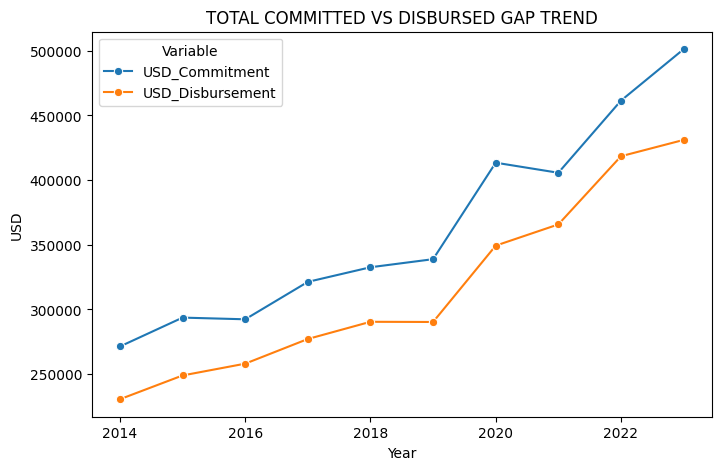

In [19]:
#convert the dataframe to long format to plot
df_melt = data2.melt(
    id_vars='Year',
    value_vars=['USD_Commitment','USD_Disbursement'],
    var_name='Variable',
    value_name='Value'
)

#Plot
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_melt,
    x='Year', 
    y='Value', 
    hue='Variable',
    marker='o'
)
plt.title("TOTAL COMMITTED VS DISBURSED GAP TREND")
plt.ylabel('USD')

There is a persistent gap between the amount committed vs the amount disbursed

### **TOP DONOR EACH YEAR**

In [20]:
data3 = data1.groupby(['Year','DonorName']).agg(
    n_projects = ('CrsID','nunique'),
    usd_commitment = ('USD_Commitment','sum'),
    usd_disb = ('USD_Disbursement','sum')
).reset_index()

In [21]:
data3.head(2)

,Year,DonorName,n_projects,usd_commitment,usd_disb
0,2014,Abu Dhabi Department of Finance,2,0.0,0.0
1,2014,Abu Dhabi Fund for Development,2,0.0,0.0


In [22]:
usd_comm = data3.sort_values(by = ['Year','usd_commitment'],ascending=False)
usd_disb = data3.sort_values(by = ['Year','usd_disb'],ascending=False)

In [23]:
commit = usd_comm.groupby('Year', as_index=False).apply(lambda df: df.nlargest(1, 'usd_commitment')).reset_index(drop=True)[['Year', 'DonorName', 'usd_commitment']]
disb = usd_disb.groupby('Year', as_index=False).apply(lambda df: df.nlargest(1, 'usd_disb')).reset_index(drop=True)[['Year', 'DonorName', 'usd_disb']]

top= commit.merge(disb[['Year','DonorName','usd_disb']],on=['Year','DonorName'],how = 'inner')

In [24]:
top.head(3)

,Year,DonorName,usd_commitment,usd_disb
0,2014,United States,28731.951450,28544.999460
1,2015,United States,30721.214044,28089.364204
2,2016,United States,32299.941952,29689.717041


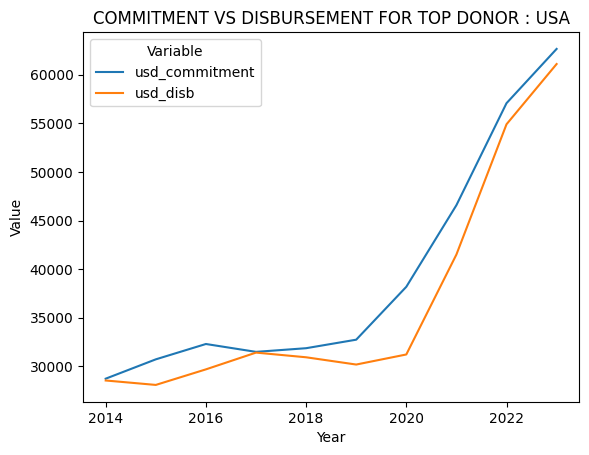

In [25]:
df_long = pd.melt(top[['Year','usd_commitment','usd_disb']], id_vars='Year', var_name='Variable', value_name='Value')
df_long

# Plot
sns.lineplot(data=df_long, x='Year', y='Value', hue='Variable')
plt.title('COMMITMENT VS DISBURSEMENT FOR TOP DONOR : USA')
plt.show()

- As seen before the amount committed is higher than the amount disbursed except for 2017 where the committed and disbursed were equal

### **TOP RECIPIENT EACH YEAR**

In [26]:
data4 = data1.groupby(['Year','RecipientName']).agg(
    usd_commitment = ('USD_Commitment','sum'),
    usd_disb = ('USD_Disbursement','sum')).reset_index()

In [27]:
usd_comm1 = data4.sort_values(by = ['Year','usd_commitment'],ascending=False)
usd_disb1 = data4.sort_values(by = ['Year','usd_disb'],ascending=False)

In [28]:
commit1 = usd_comm1.groupby('Year', as_index=False).apply(lambda df: df.nlargest(1, 'usd_commitment')).reset_index(drop=True)[['Year', 'RecipientName', 'usd_commitment']]
disb1 = usd_disb1.groupby('Year', as_index=False).apply(lambda df: df.nlargest(1, 'usd_disb')).reset_index(drop=True)[['Year', 'RecipientName', 'usd_disb']]

top1= commit1.merge(disb1[['Year','RecipientName','usd_disb']],on=['Year','RecipientName'],how = 'inner')

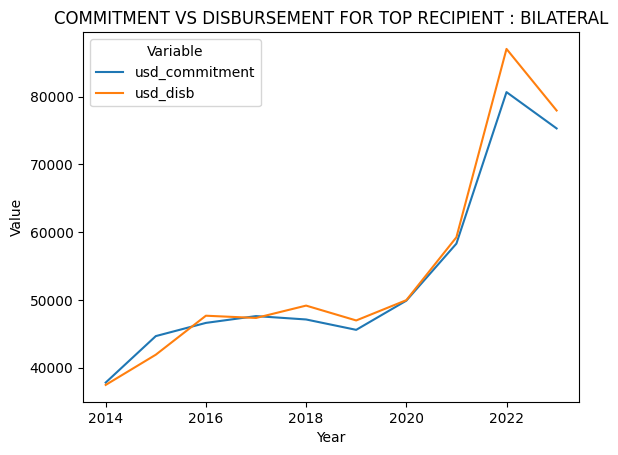

In [29]:
df_long1 = pd.melt(top1[['Year','usd_commitment','usd_disb']], id_vars='Year', var_name='Variable', value_name='Value')

# Plot
sns.lineplot(data=df_long1, x='Year', y='Value', hue='Variable')
plt.title('COMMITMENT VS DISBURSEMENT FOR TOP RECIPIENT : BILATERAL')
plt.show()

- The top recipient was noted to be bilateral organizations. Even though the commited amount was higher than the disbursed, there is some cross-overs over the years with the amount disbursed being higher that the amount committed in the recent years.

### **VOLATILITY OF COMMITMENT - DISBURSEMENT GAP**

In [30]:
#create a new column gap that is a relative measure of dirsbused and committed difference
data1["Gap"] = (data1["USD_Commitment"] - data1["USD_Disbursement"]) / data1["USD_Commitment"]

In [31]:
grp = (
    data1.groupby(["DonorName","Year"])["Gap"]
      .mean()
      .reset_index()
)

In [32]:
cv_gap = (
    grp.groupby("DonorName")["Gap"]
       .agg(["mean","std"])
       .assign(CV=lambda x: x["std"]/x["mean"])
       .sort_values("CV", ascending=False)
       .head(15)
       .reset_index()
)

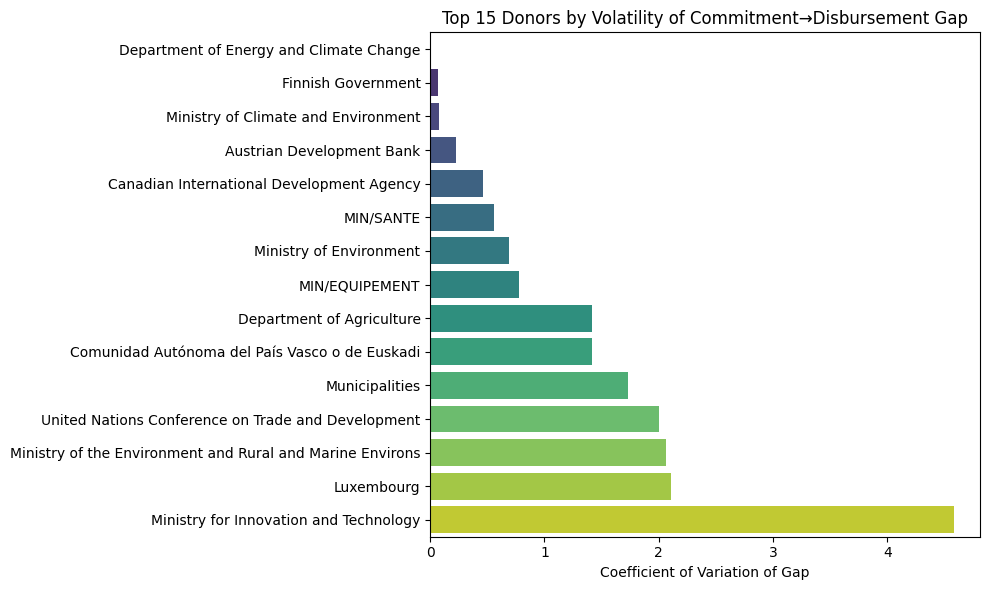

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=cv_gap.sort_values("CV", ascending=True),
    x="CV", y="DonorName",
    palette="viridis"
)
plt.xlabel("Coefficient of Variation of Gap")
plt.ylabel("")
plt.title("Top 15 Donors by Volatility of Commitment→Disbursement Gap")
plt.tight_layout()
plt.show()

- Donors with low CV are more reliable at converting commitments into paid outflows on a consistent schedule which is useful for recipients’ cash-flow planning.
- A few entities (e.g., Ministry for Innovation & Technology, Luxembourg) show the largest year-to-year swings, indicating unpredictable execution versus pledges.
- Agencies like the Dept. of Energy & Climate Change and the Finnish Government sit near zero volatility, meaning commitments and disbursements track closely year after year.

##  -----------------1.2. GENDER-CLIMATE CO-BENEFIT MAPPING

### Global Bucket‑Share Comparison

In [34]:
#Define the co‑benefit buckets
both    = (data1["Gender"]>0) & ((data1["ClimateMitigation"]>0)|(data1["ClimateAdaptation"]>0))
gender  = (data1["Gender"]>0) & ~both
climate = (~gender) & ((data1["ClimateMitigation"]>0)|(data1["ClimateAdaptation"]>0))

data1["Bucket"] = "Neither"
data1.loc[gender,  "Bucket"] = "Only gender"
data1.loc[climate, "Bucket"] = "Only climate"
data1.loc[both,    "Bucket"] = "Both"

In [35]:
data1[['Gender','ClimateMitigation','ClimateAdaptation']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3843382 entries, 0 to 3843381
Data columns (total 3 columns):
 #   Column             Dtype
---  ------             -----
 0   Gender             Int8 
 1   ClimateMitigation  Int8 
 2   ClimateAdaptation  int32
dtypes: Int8(2), int32(1)
memory usage: 29.3 MB


In [36]:
data1['ClimateAdaptation'].unique()

array([0, 2, 1])

Text(0.5, 1.0, 'SHARE OF PROJECTS THAT INTERSECT CLIMATE AND GENDER')

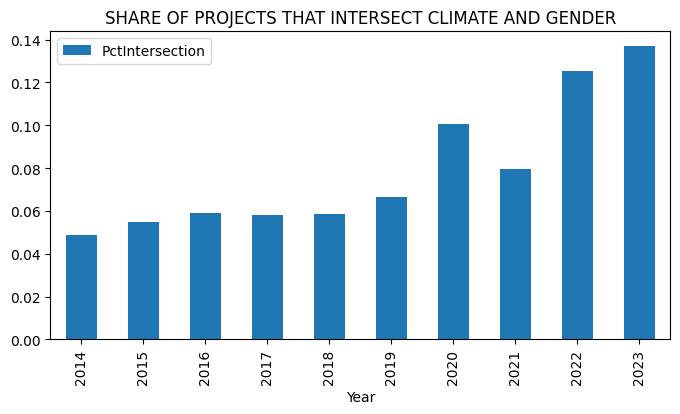

In [37]:
counts = (
   data1.assign(
        Intersection=(data1["Gender"]>0)&((data1["ClimateMitigation"]>0)|(data1["ClimateAdaptation"]>0))
    )
    .groupby("Year")["Intersection"]
    .mean()  # share of projects per year
    .reset_index(name="PctIntersection")
)
counts.plot(x="Year", y="PctIntersection", kind="bar", figsize=(8,4))
plt.title('SHARE OF PROJECTS THAT INTERSECT CLIMATE AND GENDER')


**There was a significant increase in projects bearing both climate and gender markings from 2015 to 2023.**

- Even though the project share rose in 2020, the share reduced in 2021. This could be attributed to the diversion of ODA responses to COVID-19 emrgency spending
- Major initiatives like UNFeministPlan of Action on climate (launched in 2022) and COP 27’s Gender Action Plan (adopted Nov 2022) pushed agencies to integrate gender across climate portfolios.
- In response to Ukraine crisis, COVID recovery and global biodiversity pledges, donors launched new packages in 2022–23 that explicitly bundle gender and climate resilience (e.g., cash‑for‑work for women in climate‑vulnerable areas), driving up 2023 intersection volumes.
- Large multilateral funds (Green Climate Fund, Adaptation Fund) rolled out gender‑responsive climate windows in 2023, so their share of “Both” shot up.

### TOP 15 DONORS AND THEIR CLIMATE&GENDER COBENEFIT FUNDING

In [38]:
#Summarize total disbursement per donor + bucket 
summary = (
    data1
    .groupby(["DonorName","Bucket"], observed=True)["USD_Disbursement"]
    .sum()
    .reset_index(name="Disb")
)

In [39]:
summary1 = summary.sort_values(by='Disb',ascending=False)
summary1 = summary1.head(10)

In [40]:
#Compute share by donor
summary1["TotalByDonor"] = summary1.groupby("DonorName")["Disb"].transform("sum")
summary1["Share"] = summary1["Disb"] / summary1["TotalByDonor"]

In [41]:
summary1

,DonorName,Bucket,Disb,TotalByDonor,Share
677,United States,Neither,295829.673573,295829.673573,1.0
295,International Bank for Reconstruction and Deve...,Neither,208315.741524,208315.741524,1.0
300,International Development Association,Neither,185325.396333,185325.396333,1.0
157,EU Institutions,Neither,162575.877295,162575.877295,1.0
19,Asian Development Bank,Neither,141601.283872,141601.283872,1.0
234,Germany,Neither,141230.900998,141230.900998,1.0
292,Inter-American Development Bank,Neither,98312.825437,98312.825437,1.0
322,Japan,Neither,82637.516128,82637.516128,1.0
220,France,Neither,77239.379035,77239.379035,1.0
671,United Kingdom,Neither,74092.512875,74092.512875,1.0


In [42]:
#Pivot and ensure all buckets exist
pivot = summary1.pivot(index="DonorName", columns="Bucket", values="Share").fillna(0)
for bucket in ["Both","Only climate","Only gender","Neither"]:
    if bucket not in pivot.columns:
        pivot[bucket] = 0.0
pivot = pivot[["Both","Only climate","Only gender","Neither"]]

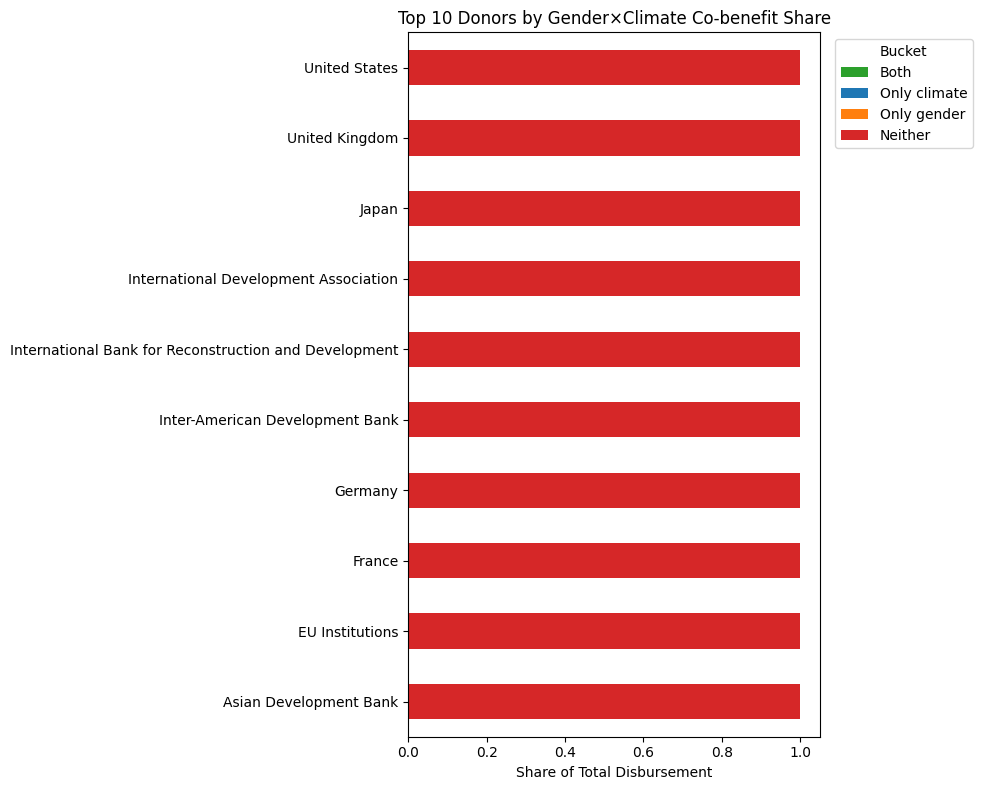

In [43]:
#Select top 10 by intersectional share 
top15 = pivot.sort_values("Both", ascending=False)

# Plot stacked horizontal bar
fig, ax = plt.subplots(figsize=(10, 8))
colors = {
    "Both": "#2ca02c",
    "Only climate": "#1f77b4",
    "Only gender": "#ff7f0e",
    "Neither": "#d62728"
}
top15.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[colors[col] for col in top15.columns]
)
ax.set_xlabel("Share of Total Disbursement")
ax.set_ylabel("")
ax.set_title(f"Top 10 Donors by Gender×Climate Co‑benefit Share")
ax.legend(title="Bucket", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


- the 10 largest financiers do not show any intersection in the disbursements
- This could be attributed to legacy portfolios, siloed thematic streams and CRS reporting conventions.

### ----TOP 10 CO-BENEFIT DONORS

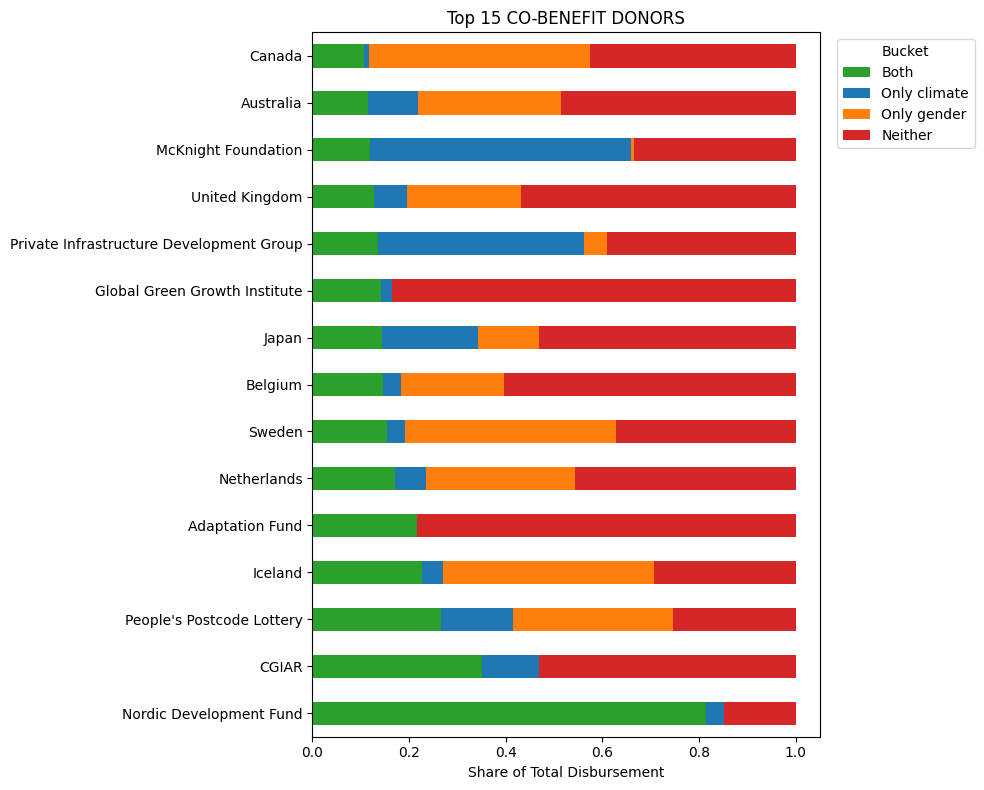

In [44]:
#Pivot and ensure all buckets exist
#Compute share by donor
summary["TotalByDonor"] = summary.groupby("DonorName")["Disb"].transform("sum")
summary["Share"] = summary["Disb"] / summary["TotalByDonor"]
pivot = summary.pivot(index="DonorName", columns="Bucket", values="Share").fillna(0)
for bucket in ["Both","Only climate","Only gender","Neither"]:
    if bucket not in pivot.columns:
        pivot[bucket] = 0.0
pivot = pivot[["Both","Only climate","Only gender","Neither"]]

top15 = pivot.sort_values("Both", ascending=False)[:15]

# Plot stacked horizontal bar
fig, ax = plt.subplots(figsize=(10, 8))
colors = {
    "Both": "#2ca02c",
    "Only climate": "#1f77b4",
    "Only gender": "#ff7f0e",
    "Neither": "#d62728"
}
top15.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[colors[col] for col in top15.columns]
)
ax.set_xlabel("Share of Total Disbursement")
ax.set_ylabel("")
ax.set_title(f"Top 15 CO-BENEFIT DONORS")
ax.legend(title="Bucket", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig("co-benefit donors.png")
plt.show()


Looking at only donors with co-benefit fund mapping, the Nordic Development Fund has the highest share of total disbursements dedicated to climate x gender projects. This is followed by CGIAR.


###  ----TREND OVER ROLLING WINDOWS FOR THE TOP 5 Co-Benefit Donors

In [45]:
data2 = data1[data1['Bucket']=='Both']

In [46]:
data2.head()

,Year,DonorCode,DEDonorcode,DonorName,AgencyCode,AgencyName,CrsID,ProjectNumber,InitialReport,RecipientCode,...,Gender,Environment,DIG,RMNCH,Biodiversity,ClimateMitigation,ClimateAdaptation,CommitmentDate,Gap,Bucket
128,2014,9,PRT,Portugal,99.0,Miscellaneous,2014010671,10671,1.0,244,...,1,2,2,<NA>,0,0,2,2014-01-01,0.0,Both
318,2014,3,DNK,Denmark,1.0,Ministry of Foreign Affairs,2004001259,104.BKF.814-200-2,3.0,287,...,1,1,0,<NA>,0,1,0,2004-10-20,NaN,Both
362,2014,7,NLD,Netherlands,1.0,Ministry of Foreign Affairs of the Netherlands,2011000490,23253,3.0,238,...,1,2,0,0,0,0,1,<NA>,-inf,Both
498,2014,9,PRT,Portugal,99.0,Miscellaneous,2014010664,10664,1.0,230,...,1,2,0,<NA>,0,0,2,2014-01-01,0.0,Both
787,2014,5,DEU,Germany,7.0,Federal Foreign Office,2014008214,6607141,8.0,425,...,1,2,2,0,1,0,2,2014-05-20,0.0,Both


In [47]:
data2.shape

(174158, 61)

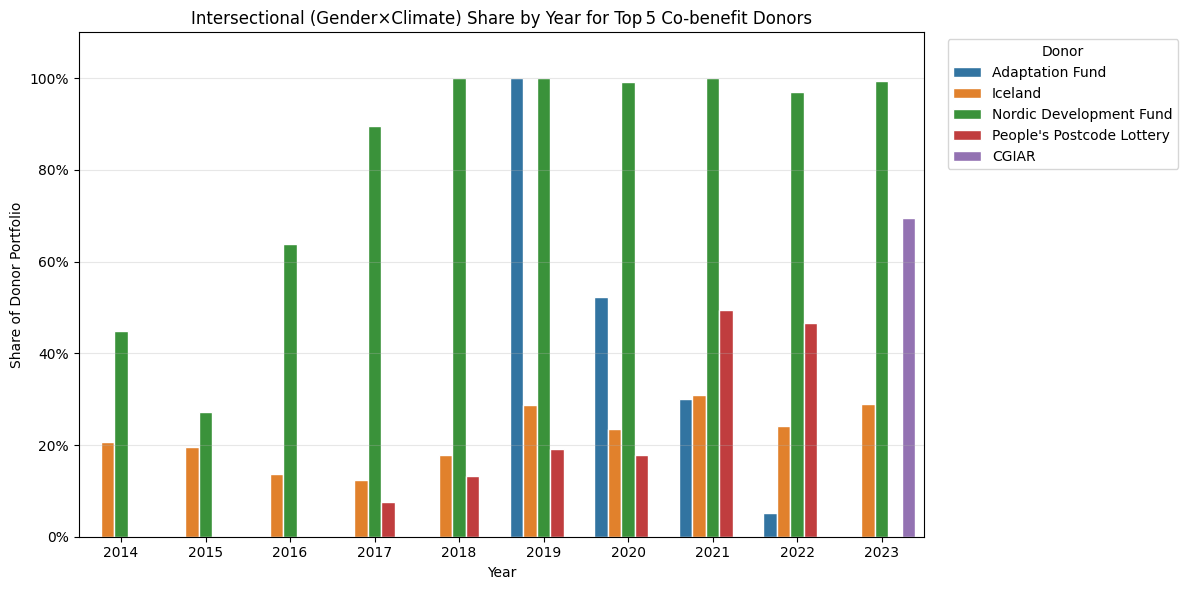

In [48]:

# 2) Recalculate annual intersectional share per donor
annual_tot = (
    data1
    .groupby(["DonorName","Year"])["USD_Disbursement"]
    .sum().reset_index(name="TotalDisb")
)

annual_int = (
    data2
    .groupby(["DonorName","Year"])["USD_Disbursement"]
    .sum().reset_index(name="InterDisb")
)

annual = pd.merge(
    annual_tot, annual_int,
    on=["DonorName","Year"], how="left"
).fillna({"InterDisb": 0})
annual["Share"] = annual["InterDisb"] / annual["TotalDisb"]

# 3) Filter to the top‑5 from Panel 1
top5 = top15.index[:5].tolist()  # reuse your top15 index
trend = annual[annual["DonorName"].isin(top5)]

# 4) Draw grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=trend,
    x="Year",
    y="Share",
    hue="DonorName",
    palette="tab10",
    edgecolor="w"
)
plt.title("Intersectional (Gender×Climate) Share by Year for Top 5 Co-benefit Donors")
plt.ylabel("Share of Donor Portfolio")
plt.xlabel("Year")
plt.ylim(0, trend["Share"].max() * 1.1)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.0%}")
)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Donor", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


**NORDIC FUND**
 - Started at 45% in 2014 and has risen to 100% making intersectional projects its core focus
 
**ICELAND**
 - The focus has been fairly stable at around 15-30%. However from these we can see intersectional projects has still remained secondary
 
**ADAPTATION FUND**
 - Absent before 2019 with 100% prjects have intersectional markers in 2019. this however decreased and no intersectional projects were noted in 2023
 
**PEOPLES' POSTCODE LOTTERY**
 - First intersectional markers noted in 2019 and increased steadily until 2021. In 2022, even though a decrease was noted, it still remained steadily high indicating a core focus. However no intersectional markers were noted in 2023.

1. CGIAR (ONE CGIAR, HER+ platform,dedicated co-benefit funds)
2. Iceland (whole-of-government gender policy,arctic&climate resilience plans,Icelandic Development Cooperation Roadmap)
3. Netherlands(Gender&Climate action plan(2020),Orange KNowledge program,private sector initiatives)
4. Denmark(Danida 2021 strategy, Green climate envelope,Local Womens' climate fund)
5. Belgium(Gender & Sustainable Development Plan (2019–24),Regional Co‑financing Windows,EU Presidency & Global Advocacy)

- in 2019,CGIAR unified its centers and under the 'One CGIAR' model and in 2020 rolled out the 2030 research & innovation strategy. The strategy elevates Gender Equality, Youth&Social Inclusion alongside climate adaptation and mitigation as core impact areas.
- in 2023, CGIAR formed the "Transformation system inititives" which pooled funding, research programs and marker reporting tools to esure new climate smart projects were also assessed for gender imoact and vice versa.
- The HER+ platform was created to mainstream gender across all impact areas, including climate. By building capacity in climate‑smart agriculture combined with women’s economic empowerment and deploying unified marker guidance across its centers, HER+ has driven a surge in projects coded with both the gender and climate DAC markers

###  ----GLOBAL CLIMATE X GENDER SHARES

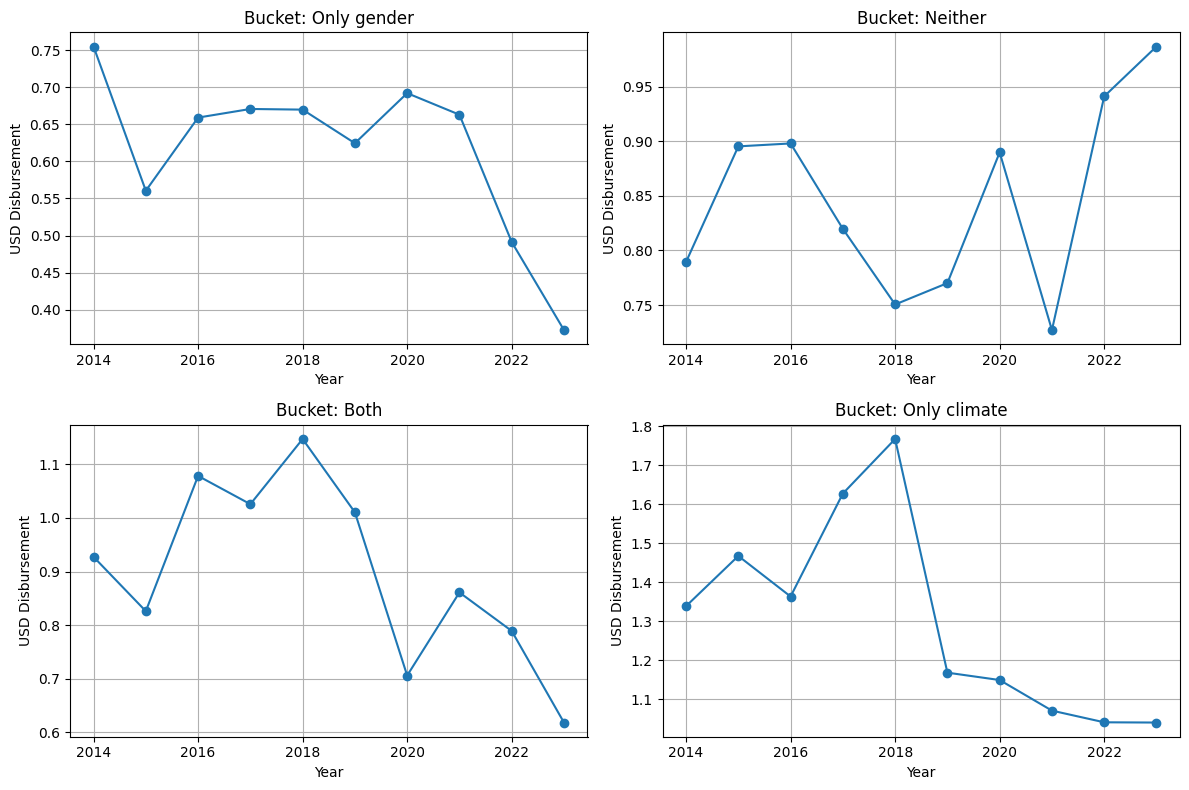

In [49]:
# assume data1 is your DataFrame with ['Bucket','Year','USD_Disbursement']
unique_buckets = data1['Bucket'].unique()
n_buckets = len(unique_buckets)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
axes = axes.flatten()

#Plot each bucket
for idx, ax in enumerate(axes):
    if idx < n_buckets:
        bucket = unique_buckets[idx]
        bucket_df = data1[data1['Bucket'] == bucket]
        by_year = bucket_df.groupby('Year')['USD_Disbursement']\
                           .mean().reset_index()
        
        ax.plot(by_year['Year'], by_year['USD_Disbursement'], marker='o')
        ax.set_title(f"Bucket: {bucket}")
        ax.set_xlabel("Year")
        ax.set_ylabel("USD Disbursement")
        ax.grid(True)
    else:
        # remove unused subplot
        fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [50]:
bucket_agg = data1.groupby(['Year','Bucket'])['USD_Disbursement'].sum().reset_index()

In [51]:
bucket_agg.head()

,Year,Bucket,USD_Disbursement
0,2014,Both,6759.291347
1,2014,Neither,188021.543141
2,2014,Only climate,9104.853411
3,2014,Only gender,26652.125651
4,2015,Both,6590.114733


<Axes: xlabel='Year', ylabel='USD_Disbursement'>

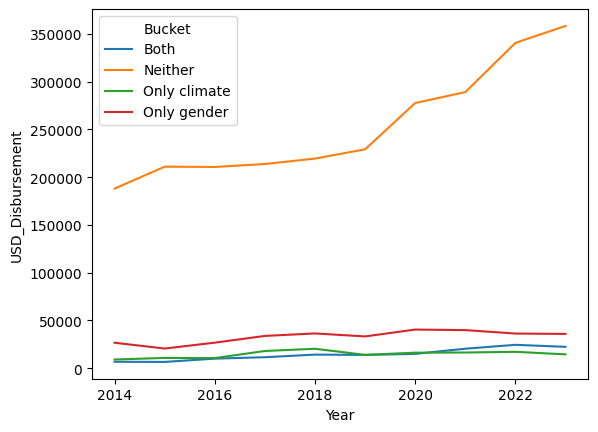

In [52]:
sns.lineplot(data = bucket_agg,x='Year',y=bucket_agg['USD_Disbursement'],hue='Bucket')

###  ----POLICY MARKER CONCURRENCE

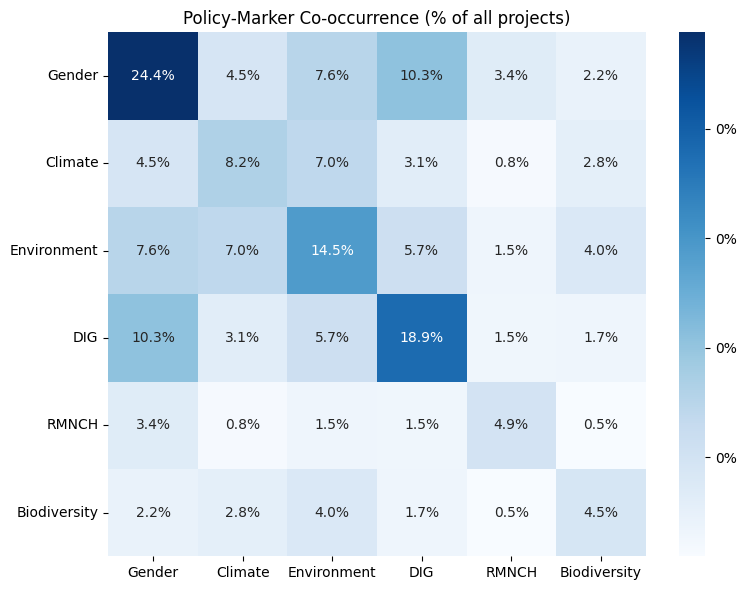

In [119]:
#Create a combined Climate flag
data1["Climate"] = (
    (data1["ClimateMitigation"] > 0) |
    (data1["ClimateAdaptation"] > 0)
)

#Define the six markers
markers = ["Gender","Climate","Environment","DIG","RMNCH","Biodiversity"]

#Build a boolean DataFrame (1 if marker >0, else 0)
df_flags = data1[markers].gt(0).fillna(False).astype(int)

#Compute co‑occurrence counts and convert to share of total projects
co_counts = df_flags.T.dot(df_flags)
co_share  = co_counts / len(df)

#Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    co_share,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    cbar_kws={"format":"%.0f%%"}
)
plt.title("Policy‑Marker Co‑occurrence (% of all projects)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('policy markers.png')
plt.show()


- Gender is the most common marker followed by digital inclusion and environment
- Many gender-focused initiatives include envrionmental and digital initiatives.
- Most climate coded projects are also marked as envirnment.
- Reproductive maternal health (RMNCH) almost always flags gender
- Biodiversity projects almost always carry an environmental marker

- Gender × Climate remains a major gap: only ~7% of all activities address both simultaneously.

- Digital inclusion is largely decoupled from other agendas—an area ripe for integrated pilots (e.g., digital tools for climate‑resilient women farmers).

- Maternal health (RMNCH) seldom intersects with climate or digital work, suggesting a missed opportunity amid growing evidence that climate shocks disproportionately affect maternal and child health.

# 2. AID DATA

- SDG1 : No poverty
- SDG2 : Zero hunger
- SDG3 : Good health and well being
- SDG4 : Quality education
- SDG5 : Gender equality
- SDG6 : Water and sanitation
- SDG7 : Affordable and clean energy
- SDG8 : Decent work and economic growth
- SDG9 : Industry Innovation and infrastructure
- SDG10 : Reduced Inequalities
- SDG11 : Sustainable cities and communities
- SDG12 : Responsible consumption and production
- SDG13 : Climate action
- SDG14 : Life below water
- SDG15 : Life on land
- SDG16 : Peace,Justice and strong institutions
- SDG17 : Patnerships for the goals

In [54]:
def load_large_csv_chunked(filename, chunksize=50000):
    """Load large CSV in chunks and combine"""
    chunks = []

    # Read in chunks
    for chunk in pd.read_csv(filename, chunksize=chunksize, low_memory=False):
        chunks.append(chunk)

    # Combine all chunks
    df = pd.concat(chunks, ignore_index=True)
    return df

# Load using chunking method
print("Loading dataset using pandas chunking...")
aiddata = load_large_csv_chunked('Financing_the_2030_Agenda_for_Sustainable_Development_Dataset_Version_1_0/aiddata_agg.csv')

Loading dataset using pandas chunking...


In [55]:
aid_dask = dd.from_pandas(aiddata, npartitions=8)

In [56]:
# Get basic info about the dataset
print(f"Shape: {aid_dask.shape[0].compute()} rows x {aid_dask.shape[1]} columns")

Shape: 82959 rows x 46 columns


In [57]:
aid_dask.head()

,year,donor_code,donor_name,recipient_code,recipient_name,recipient_region,disbursement,total_proj,sdg_1_sum,sdg_1_n_proj,...,sdg_15_sum,sdg_15_n_proj,sdg_16_sum,sdg_16_n_proj,sdg_17_sum,sdg_17_n_proj,env_sum,env_n_proj,non_sdg_sum,non_sdg_n_proj
0,2010,1,Austria,55,Turkiye,Europe and Eurasia,28804294.0,7,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,89601.0,1
1,2010,1,Austria,57,Kosovo,Europe and Eurasia,17303907.0,43,2106.0,1,...,3350.0,1,12910182.0,9,0.0,0,0.0,0,810967.0,6
2,2010,1,Austria,62,Croatia,Europe and Eurasia,5920229.0,11,18882.0,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,2010,1,Austria,63,Serbia,Europe and Eurasia,13613218.0,34,74293.5,5,...,0.0,0,1209274.0,2,0.0,0,25927.0,1,1515658.0,3
4,2010,1,Austria,64,Bosnia and Herzegovina,Europe and Eurasia,32505626.0,52,13027.0,1,...,0.0,0,8676740.0,9,1854012.0,2,0.0,0,1855888.0,3


In [58]:
aid_dask['year'].unique().compute()

0    2012
0    2020
0    2010
0    2011
1    2021
0    2014
0    2015
1    2016
2    2019
0    2013
1    2017
2    2018
Name: year, dtype: int64

In [59]:
aid_data = aid_dask.compute()

In [60]:
aid_data.columns

Index(['year', 'donor_code', 'donor_name', 'recipient_code', 'recipient_name',
       'recipient_region', 'disbursement', 'total_proj', 'sdg_1_sum',
       'sdg_1_n_proj', 'sdg_2_sum', 'sdg_2_n_proj', 'sdg_3_sum',
       'sdg_3_n_proj', 'sdg_4_sum', 'sdg_4_n_proj', 'sdg_5_sum',
       'sdg_5_n_proj', 'sdg_6_sum', 'sdg_6_n_proj', 'sdg_7_sum',
       'sdg_7_n_proj', 'sdg_8_sum', 'sdg_8_n_proj', 'sdg_9_sum',
       'sdg_9_n_proj', 'sdg_10_sum', 'sdg_10_n_proj', 'sdg_11_sum',
       'sdg_11_n_proj', 'sdg_12_sum', 'sdg_12_n_proj', 'sdg_13_sum',
       'sdg_13_n_proj', 'sdg_14_sum', 'sdg_14_n_proj', 'sdg_15_sum',
       'sdg_15_n_proj', 'sdg_16_sum', 'sdg_16_n_proj', 'sdg_17_sum',
       'sdg_17_n_proj', 'env_sum', 'env_n_proj', 'non_sdg_sum',
       'non_sdg_n_proj'],
      dtype='object')

In [61]:
aid_data.describe()

,year,donor_code,recipient_code,disbursement,total_proj,sdg_1_sum,sdg_1_n_proj,sdg_2_sum,sdg_2_n_proj,sdg_3_sum,...,sdg_15_sum,sdg_15_n_proj,sdg_16_sum,sdg_16_n_proj,sdg_17_sum,sdg_17_n_proj,env_sum,env_n_proj,non_sdg_sum,non_sdg_n_proj
count,82959.000000,82959.000000,82959.000000,8.295900e+04,82959.000000,8.295900e+04,82959.000000,8.295900e+04,82959.000000,8.295900e+04,...,8.295900e+04,82959.000000,8.295900e+04,82959.000000,8.295900e+04,82959.000000,8.295900e+04,82959.000000,8.295900e+04,82959.000000
mean,2016.090780,596.160814,521.355501,3.646999e+07,30.334382,1.352095e+06,1.429742,2.682078e+06,2.954917,4.207926e+06,...,3.854560e+05,0.601864,3.286003e+06,5.095228,6.952013e+05,0.601032,2.396503e+05,0.389108,8.661012e+06,4.097325
std,3.384416,520.372162,1056.754934,2.214213e+08,101.993809,1.556135e+07,17.784943,1.971790e+07,10.333505,4.254508e+07,...,4.403770e+06,3.013300,2.870806e+07,31.206980,1.870779e+07,3.312208,6.273066e+06,2.459341,1.183821e+08,26.750522
min,2010.000000,1.000000,55.000000,-7.663994e+06,0.000000,-1.310465e+08,0.000000,-5.015259e+06,0.000000,-5.959602e+07,...,-4.439730e+05,0.000000,-1.353733e+07,0.000000,-4.969850e+05,0.000000,-4.714550e+05,0.000000,-7.850050e+05,0.000000
25%,2013.000000,21.000000,247.000000,1.543705e+05,2.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
50%,2016.000000,742.000000,342.000000,1.320231e+06,6.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
75%,2019.000000,959.000000,614.000000,9.991964e+06,24.000000,2.992050e+04,1.000000,2.012060e+05,2.000000,3.966392e+05,...,0.000000e+00,0.000000,3.227200e+05,3.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,5.431860e+05,2.000000
max,2021.000000,1647.000000,9998.000000,1.233538e+10,9139.000000,9.852537e+08,3542.000000,2.148587e+09,370.000000,3.087077e+09,...,4.229062e+08,211.000000,2.133141e+09,4288.000000,3.007180e+09,205.000000,1.308079e+09,425.000000,8.091204e+09,2360.000000


<Axes: title={'center': 'Total Disbursement Over Time'}, xlabel='year'>

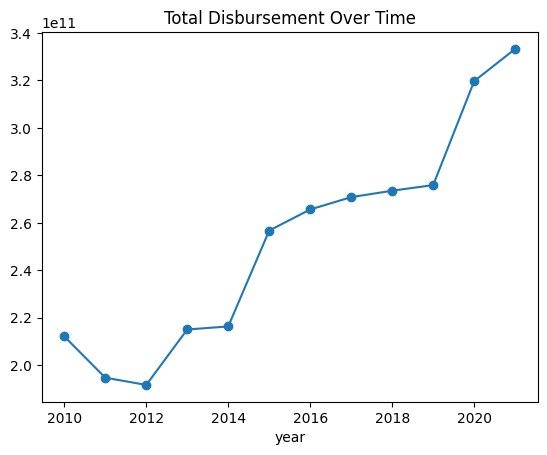

In [62]:
aid_data.groupby('year')['disbursement'].sum().plot(title='Total Disbursement Over Time', marker='o')

<Axes: ylabel='donor_name'>

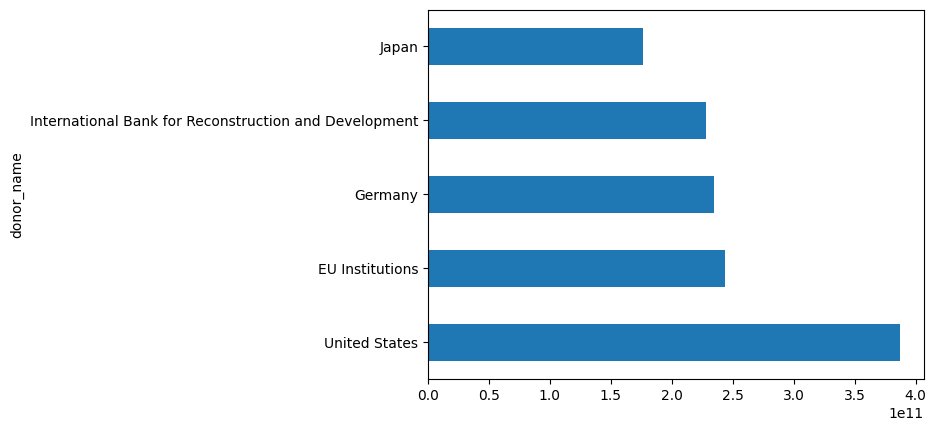

In [63]:
#top donors
aid_data.groupby('donor_name')['disbursement'].sum().sort_values(ascending=False).head(5).plot(kind='barh')

<Axes: ylabel='recipient_name'>

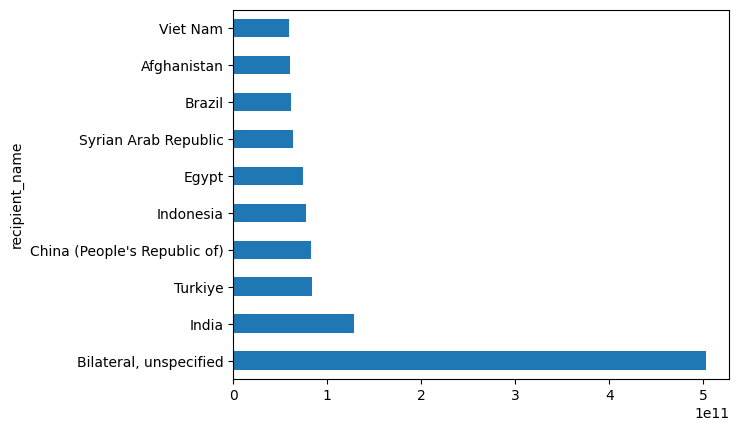

In [64]:
#top recipients
aid_data.groupby('recipient_name')['disbursement'].sum().sort_values(ascending=False).head(10).plot(kind='barh')

<Axes: ylabel='year,recipient_name'>

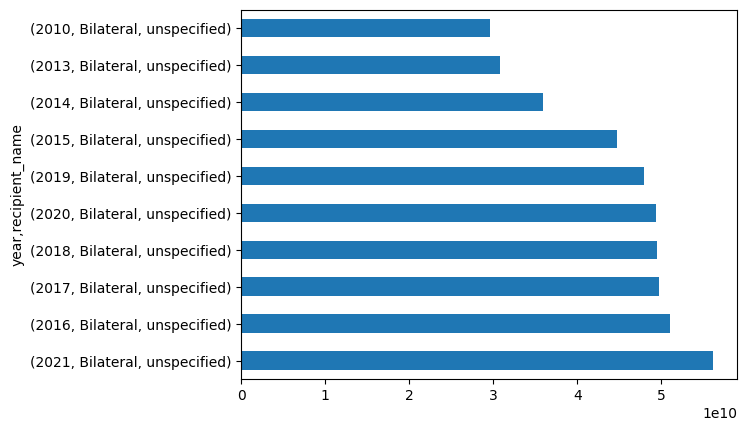

In [65]:
aid_data.groupby(['year','recipient_name'])['disbursement'].sum().sort_values(ascending=False).head(10).plot(kind='barh')

- Bialteral,unspecified organizations receive the most aid throughout all the years

<Axes: title={'center': 'Total Disbursement by SDG'}>

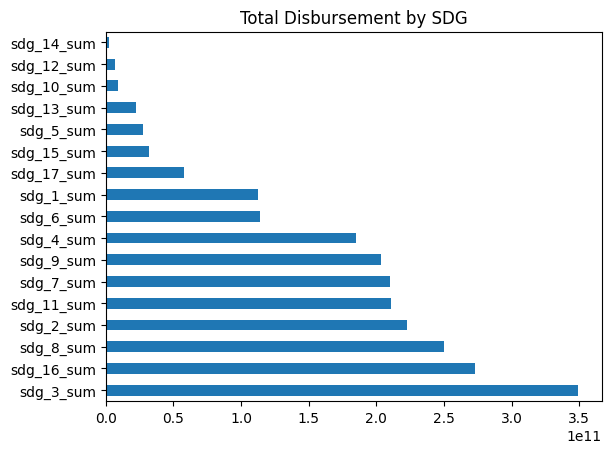

In [66]:
#Total disbursement by SDG
sdg_sum_cols = [col for col in aid_data.columns if col.startswith('sdg_') and col.endswith('_sum')]
aid_data[sdg_sum_cols].sum().sort_values(ascending=False).plot(kind='barh', title='Total Disbursement by SDG')

 - Most disbursement are clustered around a few SDGs (3-health,16-promoting peace & justice,8-decent work and 2-zero hunger)

<Axes: title={'center': 'Total Number of Projects by SDG'}>

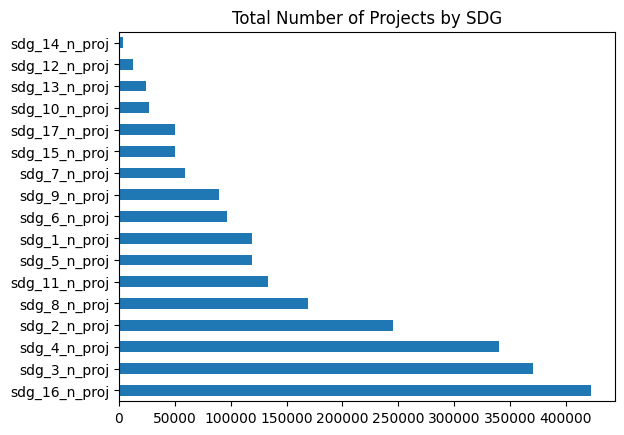

In [67]:
#total projects by sdg
sdg_proj_cols = [col for col in aid_data.columns if col.startswith('sdg_') and col.endswith('_n_proj')]
aid_data[sdg_proj_cols].sum().sort_values(ascending=False).plot(kind='barh', title='Total Number of Projects by SDG')

Considering project count- SDG16(justice and peace) has the highest no of projects followed by SDG3(health) and SDG4(education)

**The aiddata shows that the portfolio is activity-dense in governance and education but money-dense in health;jobs and food security also absorb large shares—patterns that mirror global policy commitments to universal health coverage, decent work, and zero hunger, with gender–climate mainstreaming evident and SDG marker overlap duly noted**

<Axes: >

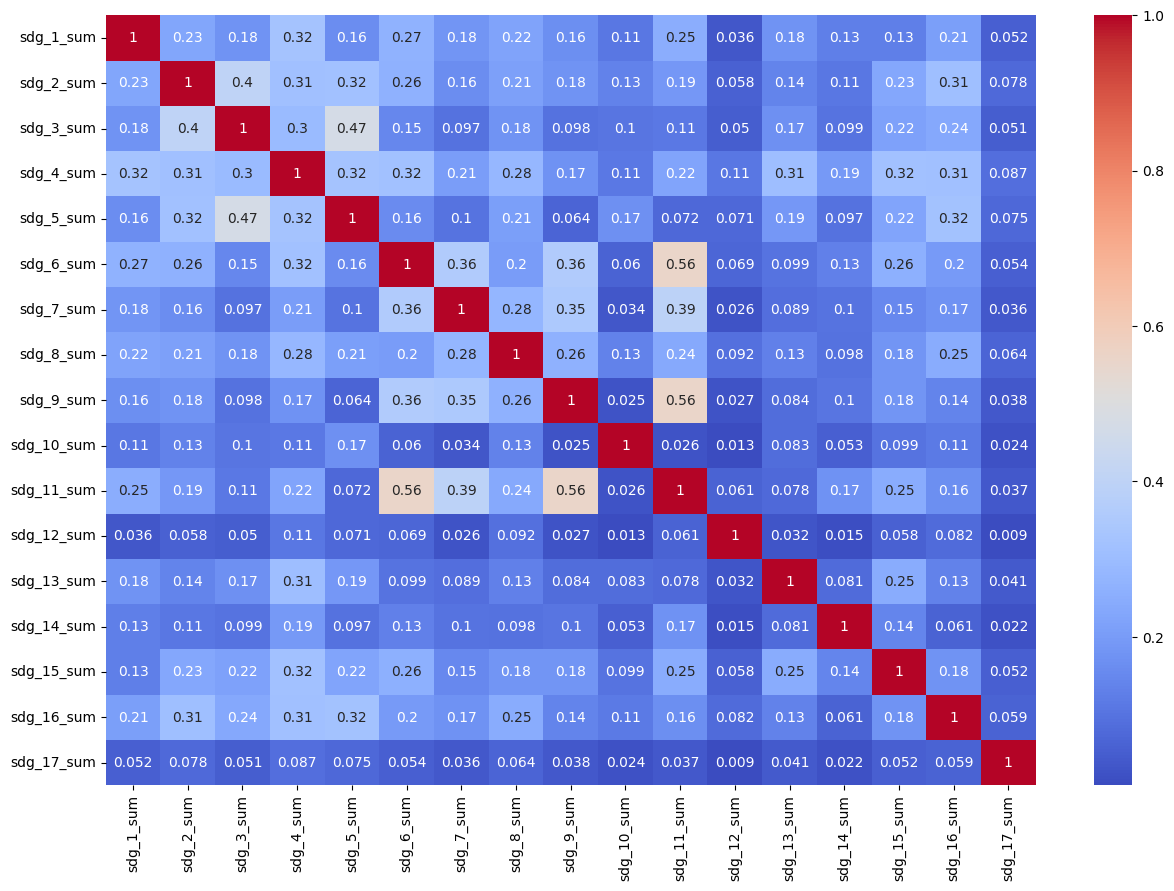

In [68]:
#correlation across all sdgs
plt.figure(figsize=(15,10))
sdg_cols = [col for col in aid_data.columns if col.startswith('sdg_') and ('_sum' in col)]
corr = aid_data[sdg_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True)

- SDG6 (clean water& sanitation) and SDG11(sustainable cities and communites) show one of the strongest correlations(~0.56). Many urban infrastructure projects might bundle city-planning investments with water sanitation improvements.
- Urban development initiatives(SDG11) also frequently include governance and institutional strengthening components(SDG16), hence the strong ocrrelation (~0.56)
- Social SDGs show moderate correlation (~0.3-0.3) :Poverty-reduction(SDG1), food security(SDG2), and health interventions(SDG3) are often designed as integrated social-protection programs, so disbursements tagged to one of these SDGs frequently overlap with the others.
- Environmental SDGs like SDG 13 (Climate Action), SDG 14 (Life Below Water) and SDG 15 (Life on Land) show relatively low correlations (< 0.15) with the core social SDGs.

<Axes: title={'center': 'Disbursement Share by Region'}>

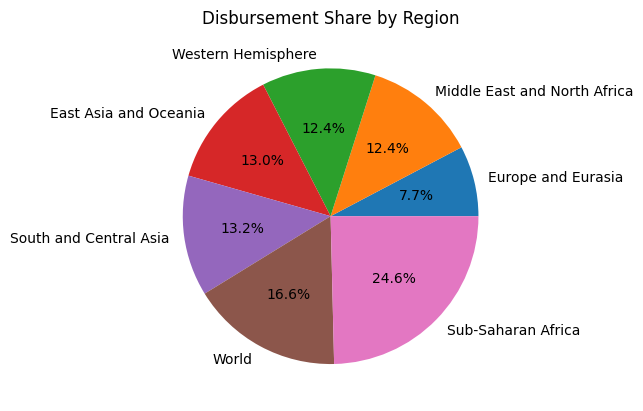

In [69]:
#disbursement by region
aid_data.groupby('recipient_region')['disbursement'].sum().sort_values().plot(
    kind='pie',
    autopct='%1.1f%%',  # show percentages with 1 decimal
    ylabel='',          # remove default y-label
    title='Disbursement Share by Region'
)


In [70]:
#sdg portfolio by donor

#Select only SDG sum columns
sdg_sum_cols = [col for col in aid_data.columns if col.startswith('sdg_') and col.endswith('_sum')]

#Melt the data to long format: (donor_name, sdg, amount)
sdg_long = aid_data[['donor_name'] + sdg_sum_cols].melt(
    id_vars='donor_name',
    var_name='sdg',
    value_name='amount in billions (USD)'
)

#Remove NaNs and group by SDG + Donor
sdg_top_donors = (
    sdg_long.dropna()
    .groupby(['sdg', 'donor_name'])['amount in billions (USD)']
    .sum()
    .reset_index()
)

sdg_top_donors['amount in billions (USD)'] = sdg_top_donors['amount in billions (USD)']/1000000000

#Get top 5 donors per SDG
top_per_sdg = (
    sdg_top_donors
    .sort_values(['sdg', 'amount in billions (USD)'], ascending=[True, False])
    .groupby('sdg')
    .head(1)
)

#Display result
tools.display_dataframe_to_user(name="Top Donors per SDG", dataframe=top_per_sdg)


Top Donors per SDG


Loading ITables v2.4.4 from the internet... (need help?)


- United States is the single top donor for 5 SDGs (2,3,5,10, 16) which are core social protection and governance goals.
- The International Bank for Reconstruction and Development (IBRD) leads in four goals (1, 7, 8, 12)—all infrastructure and economic-development targets.
- SDG 16 (Peace, Justice & Strong Institutions) stands out with over 51 billion usd from the U.S., more than 5× the next largest single-goal figure. This suggests major emphasis (or large multi-year peacebuilding packages) in governance and institution-strengthening.

- Germany tops both SDG 13 (Climate Action) and SDG 15 (Life on Land), and IDA leads SDG 14 (Life Below Water).

- Japan is the largest funder of water & sanitation (SDG 6) and urban development (SDG 11)—reflecting its focus on infrastructure and resilience projects in partner countries.

In [71]:
use_cols = ['year', 'donor_code', 'donor_name', 'recipient_code', 'recipient_name',
       'recipient_region', 'disbursement', 'total_proj', 'sdg_5_sum',
       'sdg_5_n_proj', 'sdg_13_sum',
       'sdg_13_n_proj', 'env_sum', 'env_n_proj', 'non_sdg_sum',
       'non_sdg_n_proj']

In [72]:
aid_data1 = aid_data[use_cols]

In [73]:
aid_data1.head()

,year,donor_code,donor_name,recipient_code,recipient_name,recipient_region,disbursement,total_proj,sdg_5_sum,sdg_5_n_proj,sdg_13_sum,sdg_13_n_proj,env_sum,env_n_proj,non_sdg_sum,non_sdg_n_proj
0,2010,1,Austria,55,Turkiye,Europe and Eurasia,28804294.0,7,0.0,0,0.0,0,0.0,0,89601.0,1
1,2010,1,Austria,57,Kosovo,Europe and Eurasia,17303907.0,43,173298.0,2,0.0,0,0.0,0,810967.0,6
2,2010,1,Austria,62,Croatia,Europe and Eurasia,5920229.0,11,0.0,0,0.0,0,0.0,0,0.0,0
3,2010,1,Austria,63,Serbia,Europe and Eurasia,13613218.0,34,26142.0,1,0.0,0,25927.0,1,1515658.0,3
4,2010,1,Austria,64,Bosnia and Herzegovina,Europe and Eurasia,32505626.0,52,92288.5,2,0.0,0,0.0,0,1855888.0,3


In [74]:
aid_data1.rename(columns={'donor_code':'DonorCode','donor_name':'DonorName',"recipient_name":'RecipientName',
                         'year':'Year','recipient_code':'RecipientCode'},inplace=True)

In [75]:
# Identify who appears in both marker sets
gender_orgs  = set(aid_data1[aid_data1["sdg_5_n_proj"] > 0]["DonorName"].dropna())  \
             | set(aid_data1[aid_data1["sdg_5_n_proj"] > 0]["RecipientName"].dropna())
climate_orgs = set(aid_data1[aid_data1["sdg_5_n_proj"] > 0]["DonorName"].dropna()) \
             | set(aid_data1[aid_data1["sdg_5_n_proj"] > 0]["RecipientName"].dropna())
both_orgs    = gender_orgs & climate_orgs

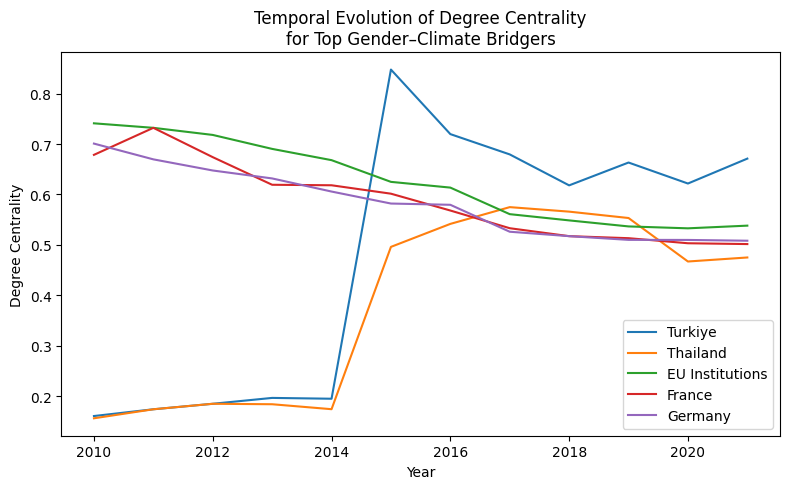

In [76]:
# Build full donor→recipient graph
G_all = nx.DiGraph()
for _, row in aid_data1.iterrows():
    u, v = row["DonorName"], row["RecipientName"]
    if pd.notna(u) and pd.notna(v):
        G_all.add_edge(u, v)

# Compute overall degree centrality
deg_all = nx.degree_centrality(G_all)

# Pick top 5 by overall degree
top5 = sorted(both_orgs, key=lambda org: deg_all.get(org, 0), reverse=True)[:5]

#Compute time series of degree‐centrality for each top5
years       = sorted(aid_data1["Year"].dropna().unique())
time_series = {org: [] for org in top5}

for year in years:
    df_y = aid_data1[aid_data1["Year"] == year]
    G_y  = nx.DiGraph()
    for _, row in df_y.iterrows():
        u, v = row["DonorName"], row["RecipientName"]
        if pd.notna(u) and pd.notna(v):
            G_y.add_edge(u, v)
    deg_y = nx.degree_centrality(G_y)
    for org in top5:
        time_series[org].append(deg_y.get(org, 0))

#Plot
plt.figure(figsize=(8, 5))
for org in top5:
    plt.plot(years, time_series[org], label=org)
plt.xlabel("Year")
plt.ylabel("Degree Centrality")
plt.title("Temporal Evolution of Degree Centrality\nfor Top Gender–Climate Bridgers")
plt.legend()
plt.tight_layout()
plt.show()


- rom 2010 through about 2013, EU Institutions, France, and Germany all sit between 0.65–0.75, meaning they were among the primary connectors in gender × climate projects.But over the decade they all drift downward toward ~0.50 by 2021.

- Turkey’s degree centrality jumps from ~0.20 in 2014 to 0.85 in 2015—becoming the single biggest connector that year—and then settles back into the 0.60–0.70 range. 2015 saw Turkey hosting key UNDP gender & climate workshops and scaling up regional refugee-related climate & gender programs. That programmatic surge would give Turkey links to many gender-tagged AND climate-tagged partners simultaneously.

- Thailand jumps from ~0.18 (2014) to ~0.50 (2015) and stays around 0.45–0.55.Thailand’s hosting of regional dialogues on women’s resilience to climate change around 2015–2016 boosted its role as a network “hub.”

# 3. COMBINING THE DATASETS

**1. CRS DATASET**

In [77]:
merge_cols = ["Year","DonorName","RecipientName"]

In [78]:
gender  = (data1["Gender"]>0)
climate = ((data1["ClimateMitigation"]>0)|(data1["ClimateAdaptation"]>0))

In [79]:
# create buckets
data1["both_tags"]    = gender & climate
data1["only_gender"]  = gender & ~climate
data1["only_climate"] = ~gender & ~climate
data1["neither"] = ~gender & ~climate
# aggregate sums by donor/recipient/year
crs_agg = (
    data1
    .groupby(["DonorName","RecipientName","Year"], as_index=False)
    .agg(
      usd_only_gender  = ("USD_Disbursement", lambda s: s[data1.loc[s.index,"only_gender"] ].sum()),
      usd_only_climate = ("USD_Disbursement", lambda s: s[data1.loc[s.index,"only_climate"]].sum()),
      usd_both_tags    = ("USD_Disbursement", lambda s: s[data1.loc[s.index,"both_tags"]].sum()),
    usd_neither    = ("USD_Disbursement", lambda s: s[data1.loc[s.index,"neither"]].sum())
    )
)

In [80]:
crs_agg.head()

,DonorName,RecipientName,Year,usd_only_gender,usd_only_climate,usd_both_tags,usd_neither
0,Abu Dhabi Department of Finance,41000,2014,0.0,0.0,0.0,0.0
1,Abu Dhabi Department of Finance,41000,2015,0.0,0.0,0.0,0.0
2,Abu Dhabi Department of Finance,41000,2016,0.0,0.0,0.0,0.0
3,Abu Dhabi Department of Finance,41000,2017,0.0,0.0,0.0,0.0
4,Abu Dhabi Department of Finance,41000,2018,0.0,0.0,0.0,0.0


**2. AIDDATA**

In [81]:
aid_data.columns

Index(['year', 'donor_code', 'donor_name', 'recipient_code', 'recipient_name',
       'recipient_region', 'disbursement', 'total_proj', 'sdg_1_sum',
       'sdg_1_n_proj', 'sdg_2_sum', 'sdg_2_n_proj', 'sdg_3_sum',
       'sdg_3_n_proj', 'sdg_4_sum', 'sdg_4_n_proj', 'sdg_5_sum',
       'sdg_5_n_proj', 'sdg_6_sum', 'sdg_6_n_proj', 'sdg_7_sum',
       'sdg_7_n_proj', 'sdg_8_sum', 'sdg_8_n_proj', 'sdg_9_sum',
       'sdg_9_n_proj', 'sdg_10_sum', 'sdg_10_n_proj', 'sdg_11_sum',
       'sdg_11_n_proj', 'sdg_12_sum', 'sdg_12_n_proj', 'sdg_13_sum',
       'sdg_13_n_proj', 'sdg_14_sum', 'sdg_14_n_proj', 'sdg_15_sum',
       'sdg_15_n_proj', 'sdg_16_sum', 'sdg_16_n_proj', 'sdg_17_sum',
       'sdg_17_n_proj', 'env_sum', 'env_n_proj', 'non_sdg_sum',
       'non_sdg_n_proj'],
      dtype='object')

In [82]:
sdg_agg = (
    aid_data
    .groupby(["donor_name","recipient_name","year"], as_index=False)
    .agg(
      total_disb = ('disbursement','sum'),
      sdg5_sum  = ("sdg_5_sum", "sum"),
      sdg13_sum = ("sdg_13_sum", "sum"),
      sdg5_n_projects_sum  = ("sdg_5_n_proj", "sum"),
      sdg13_n_projects_sum = ("sdg_13_n_proj", "sum")
    )
)

In [83]:
sdg_agg.head()

,donor_name,recipient_name,year,total_disb,sdg5_sum,sdg13_sum,sdg5_n_projects_sum,sdg13_n_projects_sum
0,Adaptation Fund,"Africa, regional",2019,2158187.0,0.0,0.0,0,0
1,Adaptation Fund,"Africa, regional",2020,2100000.0,0.0,0.0,0,0
2,Adaptation Fund,Albania,2021,630008.0,0.0,0.0,0,0
3,Adaptation Fund,Angola,2021,2338004.0,0.0,2338004.0,0,1
4,Adaptation Fund,Antigua and Barbuda,2017,1653569.0,0.0,1653569.0,0,5


In [84]:
sdg_agg.rename(columns={'year':'Year','donor_name':'DonorName','recipient_name':'RecipientName'},inplace=True)

In [85]:
#calculate share of disbursed amnt to gended and climate
sdg_agg['sdg5_share'] = sdg_agg['sdg5_sum']/sdg_agg['total_disb']
sdg_agg['sdg13_share'] = sdg_agg['sdg13_sum']/sdg_agg['total_disb']

In [86]:
sdg_agg['sdg5_sum'] = sdg_agg['sdg5_sum']/1000000
sdg_agg['sdg13_sum'] = sdg_agg['sdg13_sum']/1000000

In [87]:
sdg_agg.head()

,DonorName,RecipientName,Year,total_disb,sdg5_sum,sdg13_sum,sdg5_n_projects_sum,sdg13_n_projects_sum,sdg5_share,sdg13_share
0,Adaptation Fund,"Africa, regional",2019,2158187.0,0.0,0.000000,0,0,0.0,0.0
1,Adaptation Fund,"Africa, regional",2020,2100000.0,0.0,0.000000,0,0,0.0,0.0
2,Adaptation Fund,Albania,2021,630008.0,0.0,0.000000,0,0,0.0,0.0
3,Adaptation Fund,Angola,2021,2338004.0,0.0,2.338004,0,1,0.0,1.0
4,Adaptation Fund,Antigua and Barbuda,2017,1653569.0,0.0,1.653569,0,5,0.0,1.0


In [88]:
sdg_agg[sdg_agg[merge_cols].duplicated()]

,DonorName,RecipientName,Year,total_disb,sdg5_sum,sdg13_sum,sdg5_n_projects_sum,sdg13_n_projects_sum,sdg5_share,sdg13_share


In [89]:
crs_agg[crs_agg[merge_cols].duplicated()]

,DonorName,RecipientName,Year,usd_only_gender,usd_only_climate,usd_both_tags,usd_neither


**3. COMBINED**

In [90]:
combined = pd.merge(
    crs_agg,
    sdg_agg,
    on=["DonorName","RecipientName","Year"],
    how="inner"   # or "outer" if you want to keep all CRS or all SDG rows
)

In [91]:
combined.shape

(57414, 14)

In [92]:
combined.describe()

,Year,usd_only_gender,usd_only_climate,usd_both_tags,usd_neither,total_disb,sdg5_sum,sdg13_sum,sdg5_n_projects_sum,sdg13_n_projects_sum,sdg5_share,sdg13_share
count,57414.000000,57414.000000,57414.000000,57414.000000,57414.000000,5.741400e+04,57414.000000,57414.000000,57414.000000,57414.000000,54478.000000,54478.000000
mean,2017.716097,4.360417,9.365454,1.675060,9.365454,3.628858e+07,0.369141,0.254238,1.508047,0.323719,0.026215,0.014252
std,2.260608,30.540800,115.962499,20.499738,115.962499,2.255208e+08,3.405777,3.911674,6.218480,2.260488,0.099870,0.092802
min,2014.000000,-0.031042,-1.200000,-0.006981,-1.200000,-3.125736e+06,-0.001040,-0.000814,0.000000,0.000000,-1.380224,-0.001508
25%,2016.000000,0.000000,0.000000,0.000000,0.000000,1.448732e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2018.000000,0.000000,0.000000,0.000000,0.000000,1.236680e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2020.000000,0.174516,0.591606,0.000000,0.591606,9.574332e+06,0.001136,0.000000,1.000000,0.000000,0.000588,0.000000
max,2021.000000,1765.410075,11494.050790,1919.546301,11494.050790,1.233538e+10,221.037026,332.168807,222.000000,121.000000,1.289993,1.000000


In [93]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57414 entries, 0 to 57413
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DonorName             57414 non-null  string 
 1   RecipientName         57414 non-null  string 
 2   Year                  57414 non-null  int64  
 3   usd_only_gender       57414 non-null  float64
 4   usd_only_climate      57414 non-null  float64
 5   usd_both_tags         57414 non-null  float64
 6   usd_neither           57414 non-null  float64
 7   total_disb            57414 non-null  float64
 8   sdg5_sum              57414 non-null  float64
 9   sdg13_sum             57414 non-null  float64
 10  sdg5_n_projects_sum   57414 non-null  int64  
 11  sdg13_n_projects_sum  57414 non-null  int64  
 12  sdg5_share            54478 non-null  float64
 13  sdg13_share           54478 non-null  float64
dtypes: float64(9), int64(3), string(2)
memory usage: 7.5 MB


In [94]:
combined.columns

Index(['DonorName', 'RecipientName', 'Year', 'usd_only_gender',
       'usd_only_climate', 'usd_both_tags', 'usd_neither', 'total_disb',
       'sdg5_sum', 'sdg13_sum', 'sdg5_n_projects_sum', 'sdg13_n_projects_sum',
       'sdg5_share', 'sdg13_share'],
      dtype='object')

In [95]:
#how CRS-only-gender disbursements line up with SDG5 sums
corr_gender_sdg5 = combined["usd_only_gender"].corr(combined["sdg5_sum"])
print("Correlation USD(Only Gender) vs. SDG5:", corr_gender_sdg5)

#pivot into quartiles / bins to compare high‐low buckets
combined["gender_bin"] = pd.qcut(combined["usd_only_gender"], 4, labels=False,duplicates='drop')
pivot = combined.pivot_table(
    index="gender_bin",
    values=["usd_only_gender","sdg5_sum"],
    aggfunc="sum"
)
print(pivot)

Correlation USD(Only Gender) vs. SDG5: 0.5719997141706648
                sdg5_sum  usd_only_gender
gender_bin                               
0            3601.786664        -0.069328
1             101.892603       326.533274
2           17490.153560    250022.540853


In [96]:
#climate vs sdg13
corr_climate_sdg13 = combined["usd_only_climate"].corr(combined["sdg13_sum"])
print("Correlation USD(Only Climate) vs. SDG13:", corr_climate_sdg13)

Correlation USD(Only Climate) vs. SDG13: 0.22385059166132384


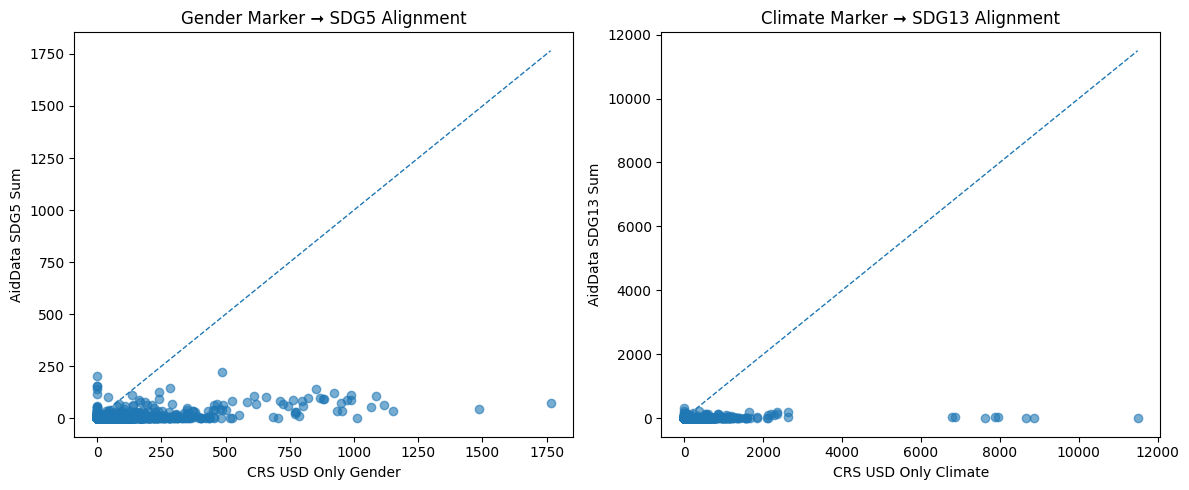

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

#Left plot: Gender marker vs. SDG5
ax = axes[0]
ax.scatter(combined["usd_only_gender"], combined["sdg5_sum"], alpha=0.6)
max_g = max(combined["usd_only_gender"].max(), combined["sdg5_sum"].max())
ax.plot([0, max_g], [0, max_g], "--", linewidth=1)
ax.set_xlabel("CRS USD Only Gender")
ax.set_ylabel("AidData SDG5 Sum")
ax.set_title("Gender Marker ➞ SDG5 Alignment")

#Right plot: Climate marker vs. SDG13
ax = axes[1]
ax.scatter(combined["usd_only_climate"], combined["sdg13_sum"], alpha=0.6)
max_c = max(combined["usd_only_climate"].max(), combined["sdg13_sum"].max())
ax.plot([0, max_c], [0, max_c], "--", linewidth=1)
ax.set_xlabel("CRS USD Only Climate")
ax.set_ylabel("AidData SDG13 Sum")
ax.set_title("Climate Marker ➞ SDG13 Alignment")

plt.tight_layout()
plt.show()



**- Most donor–country–year combinations, the CRS “only_gender” (or “only_climate”) disbursement exceeds the SDG-tagged sum. Projects flagged as gender-significant often receive more total funding under the policy-marker system than the fraction credited to SDG 5 in AidData.**
- The binary gender marker and the fractional SDG 5 tagging don’t map one-to-one—there’s systematic under- or over-reporting depending on the framework.

- CRS climate-only disbursements align somewhat better with the SDG 13 sums than the gender case.
- Climate policy markers track SDG 13 somewhat more faithfully than gender markers do SDG 5, but significant mismatches remain—especially in large-scale interventions.

## NETWORK & CLUSTER ANALYSIS

**CLUSTER ANALYSIS**

In [98]:
def safe_div(num, den):
    den = den.replace(0, np.nan)                  # avoid divide-by-zero
    out = num.div(den)
    return out.replace([np.inf, -np.inf], np.nan) .fillna(0)      

In [99]:
combined['sdg_5_13_n_projects'] = combined['sdg5_n_projects_sum'] + combined['sdg13_n_projects_sum']

In [100]:
g = combined.groupby('DonorName', as_index=False).agg({
    'usd_only_gender':  'sum',
    'usd_only_climate': 'sum',
    'usd_both_tags':    'sum',
    'usd_neither':      'sum',      # <-- build this from raw if you don’t have it yet
    'sdg5_sum':         'sum',
    'sdg13_sum':        'sum',
    'sdg_5_13_n_projects':'sum'
})

# Use the sum of the four buckets as the denominator (not a different total)
den = g[['usd_only_gender','usd_only_climate','usd_both_tags','usd_neither']].sum(axis=1).replace(0, np.nan)

g['share_gender']   = (g['usd_only_gender']  / den).fillna(0)
g['share_climate']  = (g['usd_only_climate'] / den).fillna(0)
g['share_both']     = (g['usd_both_tags']    / den).fillna(0)
g['share_neither']  = (g['usd_neither']      / den).fillna(0)

# SDG rates (stabilize)
g['sdg5_rate']  = (g['sdg5_sum']  / g['sdg_5_13_n_projects'].replace(0, np.nan)).fillna(0)
g['sdg13_rate'] = (g['sdg13_sum'] / g['sdg_5_13_n_projects'].replace(0, np.nan)).fillna(0)


In [101]:
eps = 1e-6
S = g[['share_both','share_gender','share_climate','share_neither']].clip(eps, 1)
clr = (np.log(S).T - np.log(S).mean(axis=1)).T
X_clr = clr.values

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best = None
for k in range(2,6):
    km = KMeans(n_clusters=k, n_init=50, random_state=42).fit(X_clr)
    sil = silhouette_score(X_clr, km.labels_)
    if not best or sil > best[0]:
        best = (sil, k, km.labels_)
print(f"Best k={best[1]} sil={best[0]:.3f}")
labels = best[2]
profile = g.assign(cluster=labels).groupby('cluster')[['share_both','share_gender','share_climate','share_neither','sdg5_rate','sdg13_rate']].mean()
display(profile.sort_values('share_both', ascending=False))


Best k=4 sil=0.741


,share_both,share_gender,share_climate,share_neither,sdg5_rate,sdg13_rate
cluster,,,,,,
3,0.983700,0.000000,0.008150,0.008150,0.018585,0.584470
1,0.034195,0.095887,0.182747,0.182747,0.355771,0.831741
2,0.009742,0.000000,0.495129,0.495129,0.302424,0.132064
0,0.000031,0.069808,0.465080,0.465080,0.275898,0.054614


- Cluster 0 : under tagged - very low dual tagged
- cluster 1 : SDG Intense - Mjority of the donors in this cluster are sdg labelled with non-trivial single marker labels
- cluster 2 : climate First - Majority of the donors in this cluster focus on climate projects or neither
- cluster 3 : Co-benefit leaders - These cluster contains majority of the co-benefit donors and only small portions of the segregated buckets.

In [102]:
clustered = g.assign(cluster=labels)  # g has DonorName + shares + sdg*_rate

# sizes
sizes = clustered['cluster'].value_counts().sort_index()
print(sizes)

# top donors by each emphasis (edit n)
def top_by(col, c, n=10):
    return (clustered[clustered['cluster']==c]
            .sort_values(col, ascending=False)
            [['DonorName', col, 'share_both','share_gender','share_climate','share_neither']]
            .head(n))

for c in sorted(clustered['cluster'].unique()):
    print(f"\nCluster {c} — top by share_both");   print(top_by('share_both', c, 8))
    print(f"\nCluster {c} — top by share_climate"); print(top_by('share_climate', c, 8))
    print(f"\nCluster {c} — top by share_gender");  print(top_by('share_gender', c, 8))


cluster
0     22
1    113
2      7
3      4
Name: count, dtype: int64

Cluster 0 — top by share_both
                       DonorName  share_both  share_both  share_gender  \
56                       Hungary    0.000351    0.000351      0.343238   
142               Wellcome Trust    0.000255    0.000255      0.034809   
29   Conrad N. Hilton Foundation    0.000078    0.000078      0.127330   
74             Jacobs Foundation    0.000000    0.000000      0.001400   
122       UBS Optimus Foundation    0.000000    0.000000      0.042419   
109                        Qatar    0.000000    0.000000      0.006461   
104   Omidyar Network Fund, Inc.    0.000000    0.000000      0.004224   
100   Norwegian Postcode Lottery    0.000000    0.000000      0.191908   

     share_climate  share_neither  
56        0.328206       0.328206  
142       0.482468       0.482468  
29        0.436296       0.436296  
74        0.499300       0.499300  
122       0.478790       0.478790  
109       0.4967

In [103]:
#name the clusters
centroids = (clustered.groupby('cluster')[['share_both','share_gender','share_climate','share_neither','sdg5_rate','sdg13_rate']]
             .mean()
             .assign(n_donors=sizes))
print(centroids)

# simple rule-based labels (adjust thresholds if needed)
labels_map = {}
for c, row in centroids.iterrows():
    if row['share_both'] > 0.6:         name = 'Co-benefit leaders'
    elif row['share_climate'] > 0.4:    name = 'Climate-forward'
    elif row['share_gender'] > 0.2:     name = 'Gender-forward'
    else:                               name = 'Under-tagged generalists'
    labels_map[c] = name

clustered['cluster_name'] = clustered['cluster'].map(labels_map)

         share_both  share_gender  share_climate  share_neither  sdg5_rate  \
cluster                                                                      
0          0.000031      0.069808       0.465080       0.465080   0.275898   
1          0.034195      0.095887       0.182747       0.182747   0.355771   
2          0.009742      0.000000       0.495129       0.495129   0.302424   
3          0.983700      0.000000       0.008150       0.008150   0.018585   

         sdg13_rate  n_donors  
cluster                        
0          0.054614        22  
1          0.831741       113  
2          0.132064         7  
3          0.584470         4  


In [104]:
labels_map

{0: 'Climate-forward',
 1: 'Under-tagged generalists',
 2: 'Climate-forward',
 3: 'Co-benefit leaders'}

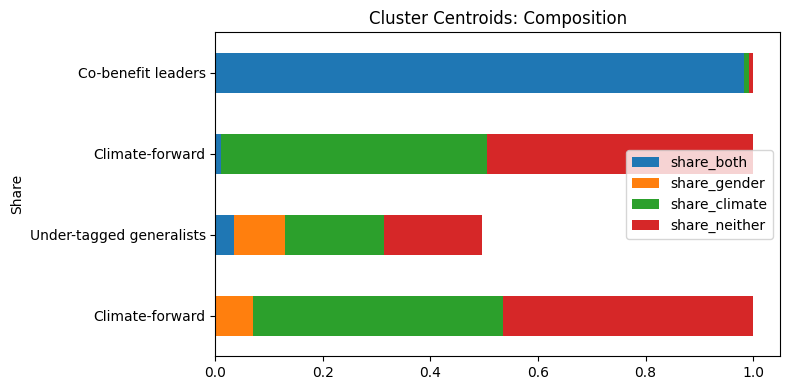

In [105]:
cent = centroids[['share_both','share_gender','share_climate','share_neither']].copy()
cent.index = [labels_map[i] for i in cent.index]
cent.plot(kind='barh', stacked=True, figsize=(8,4))
plt.ylabel('Share')
plt.title('Cluster Centroids: Composition'); plt.legend(loc='upper center', ncol=4)
plt.legend(loc='right')
plt.tight_layout()
plt.show()


In [106]:
cent = profile[['share_both','share_gender','share_climate','share_neither']]
cent.assign(gender_forward = (cent['share_gender'] > cent[['share_both','share_climate']].max(axis=1)) & 
                               (cent['share_gender'] >= 0.20))

,share_both,share_gender,share_climate,share_neither,gender_forward
cluster,,,,,
0,0.000031,0.069808,0.465080,0.465080,False
1,0.034195,0.095887,0.182747,0.182747,False
2,0.009742,0.000000,0.495129,0.495129,False
3,0.983700,0.000000,0.008150,0.008150,False


We find 4 cluster types ::
 1. C3 – Co-benefit leaders (highest Both share),
 2. C2 – Climate-first specialists (very high Only-climate + high Neither),
 3. C1 – Under-tagged generalists (no significantly dominant bucket).
 4. C0 – Climate-leaning generalists (moderate Only-climate + high Neither with a small gender slice),
 
Silhouette = 0.74: the groups are well-separated and meaningful.
**Across all the donor clusters, the share_gender is consistently low relative to share_climate and share_neither.
Co-benefit penetration is still low and climate heavy spending lacks gender integrations.**

**NETWORK ANALYSIS**

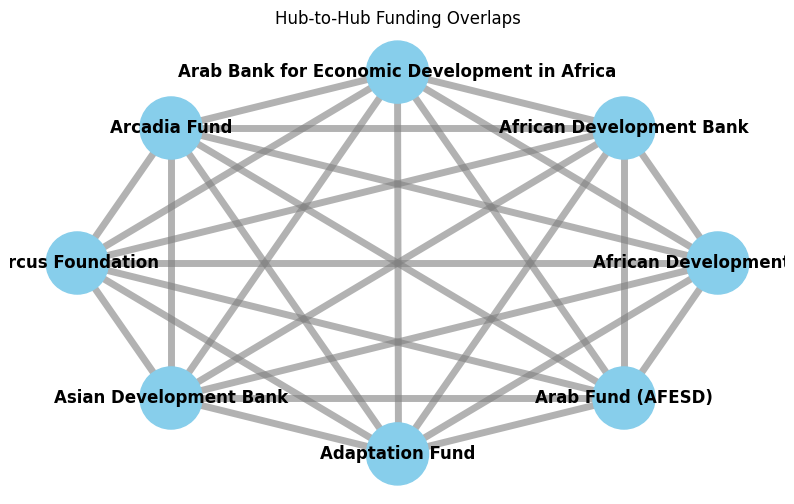

In [107]:
donors = combined['DonorName'].unique()
goals = ['OnlyGender','OnlyClimate','SDG5','SDG13','Both']
B = nx.Graph()
B.add_nodes_from(donors, bipartite=0)
B.add_nodes_from(goals, bipartite=1)

#add the weighted edges
for _, row in combined.iterrows():
    donor = row['DonorName']
    B.add_edge(donor, 'OnlyGender',   weight=row['usd_only_gender'])
    B.add_edge(donor, 'OnlyClimate',  weight=row['usd_only_climate'])
    B.add_edge(donor, 'SDG5',         weight=row['sdg5_sum'])
    B.add_edge(donor, 'SDG13',        weight=row['sdg13_sum'])
    B.add_edge(donor, 'Both',  weight=row['usd_both_tags'])
    
#link two donors if they fund the same project
donor_nodes = [n for n,d in B.nodes(data=True) if d['bipartite']==0]
G_donors = bipartite.weighted_projected_graph(B, donor_nodes)
# Build G_view as before (top 8 hubs + strong ties) ---
centrality = nx.degree_centrality(G_donors)
weights   = nx.get_edge_attributes(G_donors, "weight")
cutoff    = np.percentile(list(weights.values()), 75)

# strong‐tie subgraph
G_strong = nx.Graph(
    (u, v, d) for u,v,d in G_donors.edges(data=True)
    if d["weight"] >= cutoff
)
# top 8 hubs + their neighbors
top8 = sorted(centrality, key=centrality.get, reverse=True)[:8]

# 1. Identify the top8 hubs
top8 = sorted(centrality, key=centrality.get, reverse=True)[:8]

# 2. Induce the subgraph on just those top8 nodes
G_hub2hub = G_donors.subgraph(top8).copy()

# 3. Draw it
pos = nx.circular_layout(G_hub2hub)  # place them evenly on a circle
edge_w = [d["weight"]/max(weights.values())*5 for u,v,d in G_hub2hub.edges(data=True)]

plt.figure(figsize=(10,6))
nx.draw_networkx_nodes(G_hub2hub, pos, node_size=[centrality[n]*2000 for n in top8], node_color="skyblue")
nx.draw_networkx_edges(G_hub2hub, pos, width=edge_w, edge_color="gray", alpha=0.6)
nx.draw_networkx_labels(G_hub2hub, pos, font_weight="bold")
plt.title("Hub-to-Hub Funding Overlaps")
plt.axis("off")
plt.show()


**There is high co-funding concentration among these players**
**The larger nodes "Arab Bank for Economic Development in Africa", "Arab Fund (AFESD)", and the "African Development Bank/Fund)" act as bridging hubs. These nodes share the recipients with others and seem well placed to coordinate cross-benefiting**

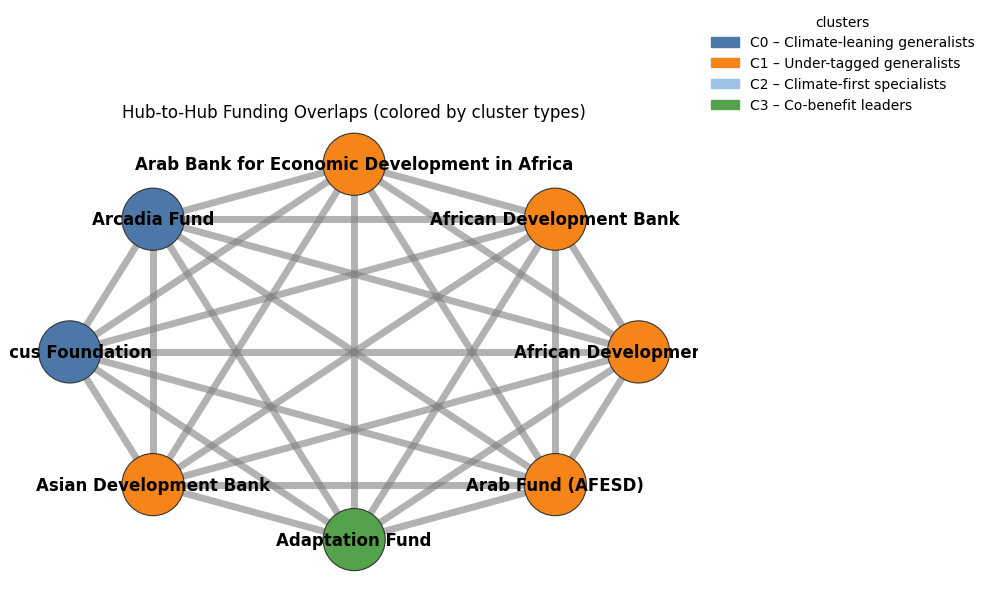

In [126]:
from matplotlib.patches import Patch

# --- cluster ID -> name and color (as you had) ---
labels_map = {0: "Climate-leaning generalists",
              1: "Under-tagged generalists",
              2: "Climate-first specialists",
              3: "Co-benefit leaders"}
cluster_colors = {0:"#4C78A8", 1:"#F58518", 2:"#9EC1E6", 3:"#54A24B", "UNK":"#9E9E9E"}

# donor -> cluster id
donor2cluster = dict(zip(clustered['DonorName'], clustered['cluster']))

# which nodes to plot
nodelist = top8  # list of 8 node names

# (recommended) make a layout on the subgraph so positions are consistent
H = G_hub2hub.subgraph(nodelist).copy()
pos = nx.circular_layout(H)  # or nx.spring_layout(H, weight='weight', k=0.6, iterations=200)

# colors & sizes must match nodelist order
node_color = [cluster_colors.get(donor2cluster.get(n, "UNK"), cluster_colors["UNK"]) for n in nodelist]
node_size  = [centrality.get(n, 1.0) * 2000 for n in nodelist]  # default 1.0 if missing

# filter edges to the subgraph and compute widths on those edges only
edgelist = list(H.edges())
weights  = [G_hub2hub[u][v].get('weight', 1.0) for u, v in edgelist]
w_max    = max(weights) if weights else 1.0
edge_widths = [(w / w_max) * 5 for w in weights]

plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(H, pos, nodelist=nodelist, node_size=node_size,
                       node_color=node_color, linewidths=0.8, edgecolors="#333333")
nx.draw_networkx_edges(H, pos, edgelist=edgelist, width=edge_widths, edge_color="gray", alpha=0.6)
nx.draw_networkx_labels(H, pos, {n: n for n in nodelist}, font_weight="bold")

plt.title("Hub-to-Hub Funding Overlaps (colored by cluster types)")
plt.axis("off")

# legend driven by the same mapping
handles = [Patch(color=cluster_colors[c], label=f"C{c} – {labels_map[c]}") for c in [0,1,2,3]]
plt.legend(handles=handles, loc="lower left", frameon=False, title="clusters", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('hub funding overlap.pdf')
plt.show()

Among the big hubs, most are unddertagged with two in the climate leaning hubs. only one hub (Adaptation fund) leans towards the co-benefit funding cluster.

In [109]:
print("C0 :Climate-leaning generalists")
print("C1 :Under-tagged generalists")
print("C2 :Climate-first specialists")
print("C3 :Co-benefit leaders")
print("-----------------------------------------")

#Map donors -> cluster and attach as node attribute
donor2cluster = dict(zip(clustered['DonorName'], clustered['cluster']))
nx.set_node_attributes(G_hub2hub, donor2cluster, name='cluster')

#Edge table with cluster pair labels
rows = []
for u,v,d in G_hub2hub.edges(data=True):
    w = float(d.get('weight', 0.0))
    cu, cv = donor2cluster.get(u, None), donor2cluster.get(v, None)
    # canonical pair label (smallest-first)
    pair = f"C{min(cu,cv)}-C{max(cu,cv)}" if (cu is not None and cv is not None) else "UNK"
    same = (cu == cv)
    rows.append((u,v,w,cu,cv,pair,same))
E = pd.DataFrame(rows, columns=['A','B','w','cA','cB','pair','same'])

#Cross-vs-same cluster overlap shares + breakdown by pair-type
total_w = E['w'].sum()
by_type = E.groupby('pair')['w'].sum().sort_values(ascending=False)
cross_share = by_type.drop(labels=[f"C{i}-C{i}" for i in range(4) if f"C{i}-C{i}" in by_type.index], errors='ignore').sum() / (total_w if total_w>0 else 1.0)
print(f"Cross-cluster overlap share: {100*cross_share:.1f}%")

print("\nOverlap weight by cluster-pair (descending):")
display((by_type / total_w).rename('share_of_total').to_frame().style.format({'share_of_total':'{:.1%}'}))

#“Conversion corridors”: edges between C3↔C1 and C3↔C0 (top 10 by weight)
corridors_mask = E['pair'].isin(['C1-C3','C0-C3'])
corridors = E[corridors_mask].sort_values('w', ascending=False).head(10)
print("\nTop 10 C3↔(C1 or C0) corridors by weight:")
display(corridors[['A','B','w','pair']])

#Broker strength of nodes
# Weighted degree (strength)
deg_w = dict(G_hub2hub.degree(weight='weight'))
deg_w_tbl = pd.Series(deg_w, name='weighted_degree').sort_values(ascending=False).to_frame()

# Betweenness centrality:
# If 'weight' is strength (higher=closer), use inverse for distances
for u,v,d in G_hub2hub.edges(data=True):
    d['inv_w'] = 1.0 / (float(d.get('weight', 0.0)) + 1e-9)

bet_inv = nx.betweenness_centrality(G_hub2hub, weight='inv_w', normalized=True)
bet_tbl = pd.Series(bet_inv, name='betweenness_invW').sort_values(ascending=False).to_frame()

brokers = (deg_w_tbl.join(bet_tbl, how='outer')
                     .join(pd.Series(donor2cluster, name='cluster'), how='left')
                     .sort_values(['betweenness_invW','weighted_degree'], ascending=False))
print("\nTop brokers (by betweenness on inverse-weight distances):")
display(brokers.head(10))

#Assortativity by cluster (negative => cross-type mixing; positive => same-type clustering)
assort = nx.attribute_assortativity_coefficient(G_hub2hub, 'cluster')
print(f"\nAssortativity by cluster: {assort:.3f}")

#Overall overlap concentration (HHI) across all pairs
hhi = ((E['w']/total_w)**2).sum() if total_w>0 else np.nan
print(f"Overall pairwise overlap concentration (HHI): {hhi:.3f}")

# (Optional) Pretty summary you can paste into a slide
summary = {
    "Cross-cluster overlap (%)": round(100*cross_share,1),
    "Assortativity (cluster)": round(assort,3),
    "HHI (pair concentration)": round(hhi,3)
}
pd.DataFrame.from_dict(summary, orient='index', columns=['value'])


C0 :Climate-leaning generalists
C1 :Under-tagged generalists
C2 :Climate-first specialists
C3 :Co-benefit leaders
-----------------------------------------
Cross-cluster overlap share: 60.7%

Overlap weight by cluster-pair (descending):


,share_of_total
pair,
C0-C1,35.7%
C1-C1,35.7%
C1-C3,17.9%
C0-C3,7.1%
C0-C0,3.6%



Top 10 C3↔(C1 or C0) corridors by weight:


,A,B,w,pair
0,African Development Fund,Adaptation Fund,5.0,C1-C3
7,African Development Bank,Adaptation Fund,5.0,C1-C3
13,Arab Bank for Economic Development in Africa,Adaptation Fund,5.0,C1-C3
18,Arcadia Fund,Adaptation Fund,5.0,C0-C3
22,Arcus Foundation,Adaptation Fund,5.0,C0-C3
25,Asian Development Bank,Adaptation Fund,5.0,C1-C3
27,Adaptation Fund,Arab Fund (AFESD),5.0,C1-C3



Top brokers (by betweenness on inverse-weight distances):


,weighted_degree,betweenness_invW,cluster
Adaptation Fund,35,0.0,3
African Development Bank,35,0.0,1
African Development Fund,35,0.0,1
Arab Bank for Economic Development in Africa,35,0.0,1
Arab Fund (AFESD),35,0.0,1
Arcadia Fund,35,0.0,0
Arcus Foundation,35,0.0,0
Asian Development Bank,35,0.0,1



Assortativity by cluster: -0.143
Overall pairwise overlap concentration (HHI): 0.036


,value
Cross-cluster overlap (%),60.700
Assortativity (cluster),-0.143
HHI (pair concentration),0.036


- **~61% of the total overlap is high between different hubs showing potential for diffusion is strong**
- **The pair concentration is low signaling many viable corridors for collaboration**
- **There is no single “kingmaker” (graph is nearly complete with similar weights), so picking corridors matters more than picking one champion.**

This map shows the big funders and who they already overlap with. Most of the core is under-tagged or climate-only (orange/blue). We have one co-benefit leader (green) that’s connected to almost everyone, and about 60% of overlaps are cross-type—ideal for spreading dual-tag practices. 

## HIGH GENDER-LOW SDG5 SHARE TAGGING

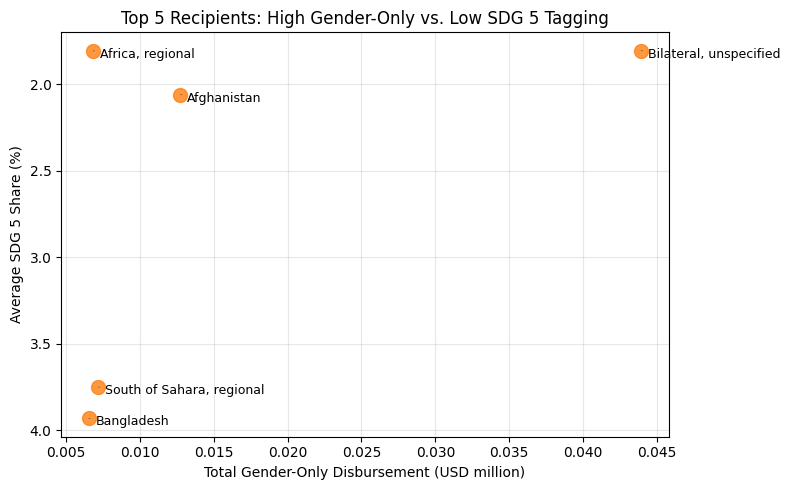

In [110]:
#Aggregate by recipient
agg = (
    combined
    .groupby("RecipientName", as_index=False)
    .agg(
        total_gender_only=("usd_only_gender", "sum"),
        avg_sdg5_share    =("sdg5_share", "mean"),
    )
)

#Score: high gender-only, low SDG5 share
agg["misalign_score"] = agg["total_gender_only"] * (1 - agg["avg_sdg5_share"])

#Pick top 5 recipients
top5 = agg.sort_values("misalign_score", ascending=False).head(5)

#Plot
fig, ax = plt.subplots(figsize=(8,5), dpi=100)

# scatter
ax.scatter(
    top5["total_gender_only"]/1e6,     # in millions
    top5["avg_sdg5_share"]*100,        # percent
    s=100, alpha=0.8, c="C1"
)

# annotate only 5 points, offset slightly
for _, row in top5.iterrows():
    ax.annotate(
        row["RecipientName"],
        xy=(row["total_gender_only"]/1e6, row["avg_sdg5_share"]*100),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.5)
    )

ax.set_xlabel("Total Gender-Only Disbursement (USD million)")
ax.set_ylabel("Average SDG 5 Share (%)")
ax.set_title("Top 5 Recipients: High Gender-Only vs. Low SDG 5 Tagging")
ax.invert_yaxis()  # so lowest SDG5 share appears at top
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- Bilateral, unspecified has the highest gender-only volume on x while still sitting near the top (low SDG-5 share)
- Regional constructs (Africa regional, SoS regional) appear, suggesting that multi-country or regional grants may be less consistently SDG-tagged than country-specific operations.
- Afghanistan and Bangladesh indicate that the issue isn’t only regional constructs; some country portfolios also show gender-only spend without SDG-5 reinforcement.

## Donor Climate–Gender Trade-Off Over Time

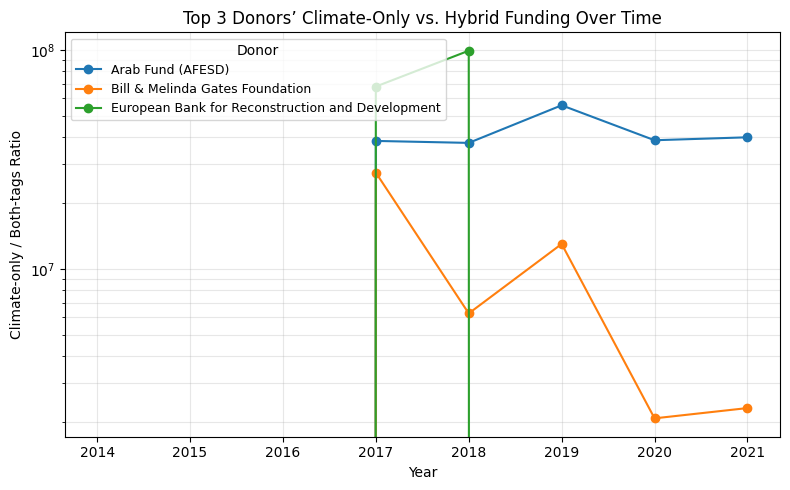

In [111]:
#Compute year‐by‐year ratio per donor
df_ratio = (
    combined
    .assign(
        ratio=lambda d: d["usd_only_climate"] / (d["usd_both_tags"] + 1e-6)
    )
    .groupby(["DonorName","Year"], as_index=False)
    .agg(ratio=("ratio","mean"))
)

#Pick top 3 donors with the largest swing
swings = (
    df_ratio
    .groupby("DonorName")["ratio"]
    .agg(lambda x: x.max() - x.min())
    .sort_values(ascending=False)
    .head(3)
    .index
)
df_plot = df_ratio[df_ratio["DonorName"].isin(swings)]

#Plot (smaller figure, only 3 lines)
fig, ax = plt.subplots(figsize=(8,5), dpi=100)
for donor, grp in df_plot.groupby("DonorName"):
    ax.plot(grp["Year"], grp["ratio"], marker="o", label=donor)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Climate-only / Both-tags Ratio")
ax.set_title("Top 3 Donors’ Climate-Only vs. Hybrid Funding Over Time")
ax.legend(title="Donor", fontsize=9, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

- AFESD has consistently high ratios over the years showing systematic climate tagging with negligible dual tagging
- Gates foundation ratio drops sharply over the years with some low movement in dual tagging
- for EBRD, a sharp spike (2018) is characteristic of zero Both that year (ratio explodes). Treat as denominator-driven, not a genuine surge in climate-only.

## SDG 13 Impact per Dollar (Top 5 Donors)

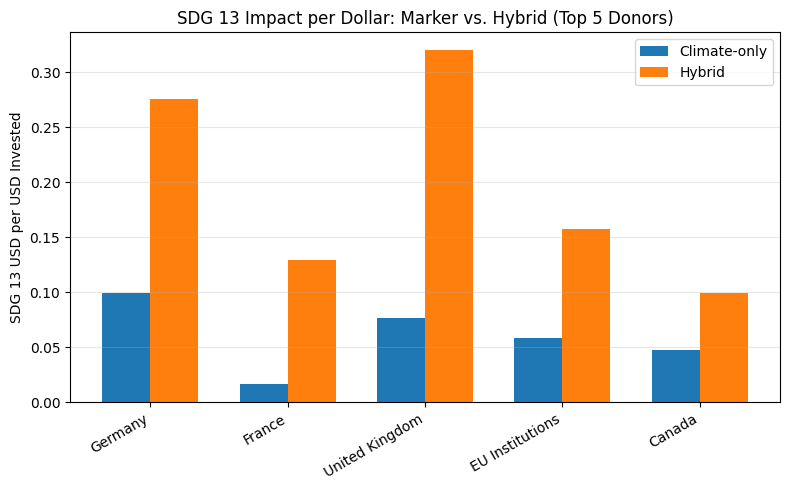

In [112]:
#Compute impact metrics by donor
imp = (
    combined
    .groupby("DonorName", as_index=False)
    .agg(
        total_climate_only=("usd_only_climate","sum"),
        total_hybrid       =("usd_both_tags","sum"),
        sdg13_total        =("sdg13_sum","sum"),
    )
    .assign(
        impact_marker = lambda d: d["sdg13_total"] / d["total_climate_only"].replace(0,np.nan),
        impact_hybrid = lambda d: d["sdg13_total"] / d["total_hybrid"].replace(0,np.nan),
    )
    .dropna(subset=["impact_marker","impact_hybrid"])
)

#Pick top 5 donors by total SDG 13 funding
top5 = imp.nlargest(5, "sdg13_total")["DonorName"]
imp_sub = imp[imp["DonorName"].isin(top5)].set_index("DonorName")

#Plot grouped bar (5 donors)
x = np.arange(len(top5))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5), dpi=100)
ax.bar(x - width/2, imp_sub["impact_marker"], width, label="Climate-only")
ax.bar(x + width/2, imp_sub["impact_hybrid"],  width, label="Hybrid")

ax.set_xticks(x)
ax.set_xticklabels(top5, rotation=30, ha="right")
ax.set_ylabel("SDG 13 USD per USD Invested")
ax.set_title("SDG 13 Impact per Dollar: Marker vs. Hybrid (Top 5 Donors)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------GENDER X CLIMATE SPILLOVER ANALYSIS ----------------

**a “spillover” means that activity in one thematic stream (gender-only or climate-only funding) in one year is systematically followed by activity in the other stream the next year.**

## 1. Does last year’s gender-only disbursement predict this year’s climate-only spend?

This asks whether surges in gender‐marker projects in Year t are followed by upticks in climate‐marker projects in Year t+1—evidence of gender→climate spillover.

In [113]:
# ============================================
# Lagged Gender → Next-Year Climate (Robust FE)
# ============================================
# Requires:
#   combined columns: ['DonorName','RecipientName','Year','usd_only_gender','usd_only_climate']
#   optional: clustered DataFrame with ['DonorName','cluster'] for heterogeneity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices

# -----------------------------
# 0) Input hygiene / type fixes
# -----------------------------
num_cols = ['usd_only_gender','usd_only_climate']
combined[num_cols] = combined[num_cols].apply(pd.to_numeric, errors='coerce')
combined['Year'] = pd.to_numeric(combined['Year'], errors='coerce')

# -----------------------------
# 1) Create lag by donor–recipient
# -----------------------------
df_sorted = combined.sort_values(['DonorName','RecipientName','Year'])
df_sorted['lag_usd_only_gender'] = (
    df_sorted.groupby(['DonorName','RecipientName'], dropna=False)['usd_only_gender'].shift(1)
)

# keep rows with both lagged gender and current climate
df_lagged = df_sorted.dropna(subset=['lag_usd_only_gender','usd_only_climate']).copy()

# normalize dtypes to avoid string[pyarrow] issues
df_lagged = df_lagged.convert_dtypes(dtype_backend='numpy_nullable')
df_lagged = df_lagged[df_lagged['Year'].notna()].copy()
df_lagged['DonorName'] = df_lagged['DonorName'].astype('category')
df_lagged['Year']      = df_lagged['Year'].astype('int64')

# -----------------------------
# 2) Baseline pooled OLS (levels)
# -----------------------------
cols = ['lag_usd_only_gender','usd_only_climate']
df_lagged[cols] = df_lagged[cols].apply(pd.to_numeric, errors='coerce').astype('float64')
mask_ok = np.isfinite(df_lagged['lag_usd_only_gender']) & np.isfinite(df_lagged['usd_only_climate'])
y_ols = df_lagged.loc[mask_ok, 'usd_only_climate'].to_numpy(dtype='float64')
X_ols = sm.add_constant(df_lagged.loc[mask_ok, 'lag_usd_only_gender'].to_numpy(dtype='float64'))
ols_pooled = sm.OLS(y_ols, X_ols).fit()
print("\n=== Baseline pooled OLS (levels) ===")
print(ols_pooled.summary())


=== Baseline pooled OLS (levels) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                 2.987e+04
Date:                Sun, 03 Aug 2025   Prob (F-statistic):               0.00
Time:                        18:40:46   Log-Likelihood:            -2.7874e+05
No. Observations:               46618   AIC:                         5.575e+05
Df Residuals:                   46616   BIC:                         5.575e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

**The single lagged regressor explains ~39% of variation—large for a one-variable pooled model.**
**The intercept is a negative baseline—this often flags scale/zero-mass issues**

In [114]:
# ----------------------------------------------
#FE (log1p-log1p) with cluster-robust SE
# ----------------------------------------------
# transform to log1p to stabilize zeros/skew
df_lagged['y'] = np.log1p(df_lagged['usd_only_climate'])
df_lagged['x'] = np.log1p(df_lagged['lag_usd_only_gender'])

# winsorize extreme right tail of x
q_hi = df_lagged['x'].quantile(0.99)
df_lagged['x'] = np.clip(df_lagged['x'], None, q_hi)

# Build design matrices with patsy (drops any NA rows consistently)
y_fe, X_fe = dmatrices('y ~ x + C(DonorName) + C(Year)',
                       data=df_lagged, return_type='dataframe', NA_action='drop')

# Align cluster groups (DonorName) to FE sample rows
groups_fe = df_lagged.loc[y_fe.index, 'DonorName']

# Fit FE with clustered SE by donor
mod_fe = sm.OLS(y_fe, X_fe).fit(cov_type='cluster', cov_kwds={'groups': groups_fe})
print("\n=== FE (log1p-log1p), clustered by Donor ===")
print(mod_fe.summary())

# Elasticity interpretation (x is log1p of lagged gender; y is log1p of current climate)
beta = mod_fe.params.get('x', np.nan)
if np.isfinite(beta):
    print(f"\nElasticity (FE): β = {beta:.3f} → +10% lagged gender ≈ {beta*10:.1f}% ↑ in climate (same donor/year controls).")


=== FE (log1p-log1p), clustered by Donor ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     1050.
Date:                Sun, 03 Aug 2025   Prob (F-statistic):          1.12e-115
Time:                        18:40:49   Log-Likelihood:                -48213.
No. Observations:               46617   AIC:                         9.672e+04
Df Residuals:                   46472   BIC:                         9.798e+04
Df Model:                         144                                         
Covariance Type:              cluster                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [115]:
beta  = mod_fe.params['x']
se    = mod_fe.bse['x']
ci_lo, ci_hi = mod_fe.conf_int().loc['x']

print(f"Elasticity (FE): β = {beta:.3f}  (95% CI: {ci_lo:.3f}, {ci_hi:.3f})")
print(f"Implication: +10% lagged gender-only ⇒ {beta*10:.1f}% (95% CI {ci_lo*10:.1f}–{ci_hi*10:.1f}%) ↑ in climate-only next year.")
print(f"            +25% lagged gender-only ⇒ {beta*25:.1f}% (95% CI {ci_lo*25:.1f}–{ci_hi*25:.1f}%) ↑")

Elasticity (FE): β = 0.722  (95% CI: 0.637, 0.808)
Implication: +10% lagged gender-only ⇒ 7.2% (95% CI 6.4–8.1%) ↑ in climate-only next year.
            +25% lagged gender-only ⇒ 18.1% (95% CI 15.9–20.2%) ↑


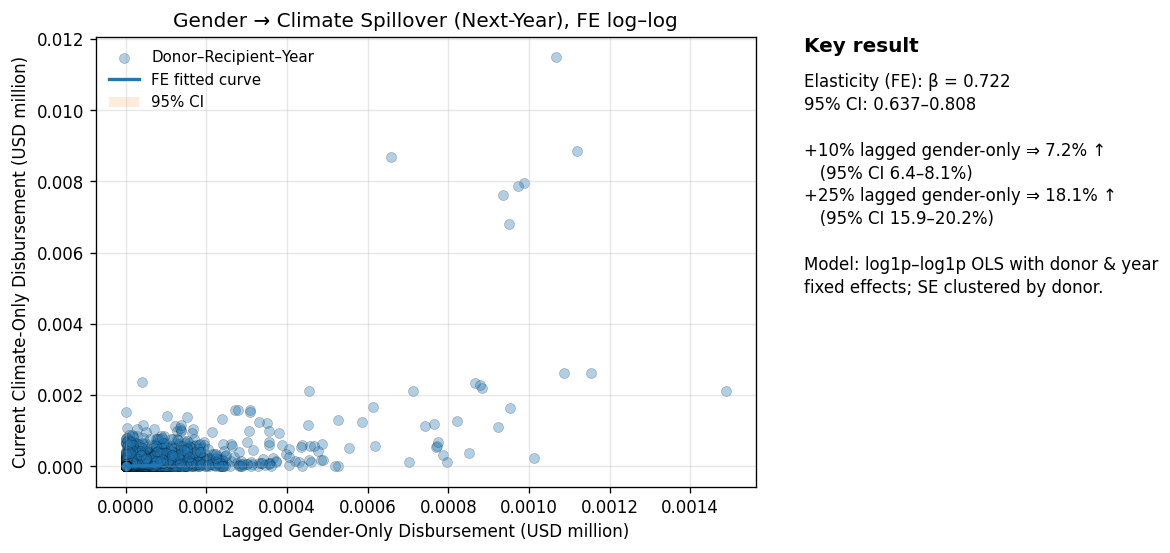

Saved: gender_to_climate_spillover_figure.png


In [116]:
#Pull slope + CI from the FE model
beta  = float(mod_fe.params['x'])
ci_lo, ci_hi = mod_fe.conf_int().loc['x'].tolist()

#Build a prediction grid (log space) and back-transform for plotting
x_grid = np.linspace(df_lagged['x'].min(), df_lagged['x'].max(), 200)
b0 = float(mod_fe.params['Intercept'])
b1 = beta
yhat_log = b0 + b1 * x_grid

# 95% CI band around fitted curve (approximate slope band)
cov = mod_fe.cov_params().loc[['Intercept','x'], ['Intercept','x']].values
var_yhat = cov[0,0] + (x_grid**2)*cov[1,1] + 2*x_grid*cov[0,1]
yhat_lo_log = yhat_log - 1.96*np.sqrt(np.clip(var_yhat, 0, np.inf))
yhat_hi_log = yhat_log + 1.96*np.sqrt(np.clip(var_yhat, 0, np.inf))

grid = pd.DataFrame({
    'x_mn': np.expm1(x_grid)/1e6,
    'y_mn': np.expm1(yhat_log)/1e6,
    'y_lo_mn': np.expm1(yhat_lo_log)/1e6,
    'y_hi_mn': np.expm1(yhat_hi_log)/1e6
})

#Prepare text for the right panel
msg = (
    f"Elasticity (FE): β = {beta:.3f}\n"
    f"95% CI: {ci_lo:.3f}–{ci_hi:.3f}\n\n"
    f"+10% lagged gender-only ⇒ {beta*10:.1f}% ↑\n"
    f"   (95% CI {ci_lo*10:.1f}–{ci_hi*10:.1f}%)\n"
    f"+25% lagged gender-only ⇒ {beta*25:.1f}% ↑\n"
    f"   (95% CI {ci_lo*25:.1f}–{ci_hi*25:.1f}%)\n\n"
    "Model: log1p–log1p OLS with donor & year\n"
    "fixed effects; SE clustered by donor."
)

#Draw figure: left chart + right text (single axes)
fig = plt.figure(figsize=(10,5), dpi=120)
ax = fig.add_axes([0.09, 0.14, 0.55, 0.75])    # left plot area
ax_text = fig.add_axes([0.68, 0.14, 0.28, 0.75])  # right text area

# Left: scatter + fit + CI band
ax.scatter(df_lagged['lag_usd_only_gender']/1e6,
           df_lagged['usd_only_climate']/1e6,
           alpha=0.35, edgecolor='k', linewidth=0.3, label='Donor–Recipient–Year')
ax.plot(grid['x_mn'], grid['y_mn'], linewidth=2, label='FE fitted curve')
ax.fill_between(grid['x_mn'], grid['y_lo_mn'], grid['y_hi_mn'], alpha=0.15, label='95% CI')

ax.set_xlabel('Lagged Gender-Only Disbursement (USD million)')
ax.set_ylabel('Current Climate-Only Disbursement (USD million)')
ax.set_title('Gender → Climate Spillover (Next-Year), FE log–log')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(alpha=0.3)

# Right: text panel (no ticks)
ax_text.axis('off')
ax_text.text(0, 1.0, "Key result", fontsize=12, fontweight='bold', va='top')
ax_text.text(0, 0.92, msg, fontsize=10, va='top', linespacing=1.35)

# Save and show
out_path = "gender_to_climate_spillover_figure.png"
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")


**A 10% increase in last year's gender only disbursement is associated with a ~7.2% higher climate-only disbursement this year (β = 0.722, 95% CI 0.637–0.808; donor & year fixed effects; cluster-robust SE by donor).**
Controlling for who the donor is and the year, we find a large and precise spillover effect: when donors increase gender-only funding, their climate-only funding tends to rise the following year—~7% for every 10% increase in gender spend.

**Next Steps**
 - Add controls (e.g. donor fixed‐effects, recipient GDP, year dummies) in a panel regression to isolate the pure spillover effect.

- Test other lags (e.g. 2-year lag) and non‐linear transformations (logs) to see if spillovers accumulate or accelerate.

- Compare to the reverse (climate‐only lag → gender‐only) for bidirectional spillover symmetry.

## 2. Which recipients exhibit the strongest two-way spillover over time?

Some countries or communities may be especially good at turning gender investments into climate action and vice versa. Identifying those “dual-spillover champions” highlights best-practice cases.

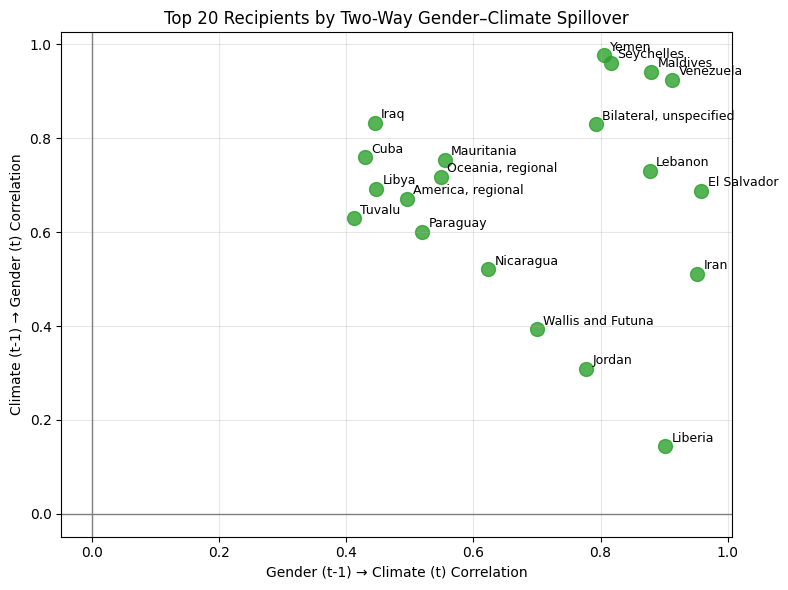

In [117]:
# 1. Aggregate by recipient and year
df_agg = (
    combined
    .groupby(["RecipientName", "Year"], as_index=False)
    .agg(
        year_gender = ("usd_only_gender", "sum"),
        year_climate= ("usd_only_climate", "sum")
    )
)

# 2. Create 1-year lag columns
df_agg = df_agg.sort_values(["RecipientName", "Year"])
df_agg["lag_gender"]  = df_agg.groupby("RecipientName")["year_gender"].shift(1)
df_agg["lag_climate"] = df_agg.groupby("RecipientName")["year_climate"].shift(1)

# 3. Compute spillover correlations per recipient
def compute_spillovers(sub):
    if sub["lag_gender"].dropna().shape[0] < 3:
        return pd.Series({"corr_g_to_c": np.nan, "corr_c_to_g": np.nan})
    corr1 = sub["lag_gender"].corr(sub["year_climate"])
    corr2 = sub["lag_climate"].corr(sub["year_gender"])
    return pd.Series({"corr_g_to_c": corr1, "corr_c_to_g": corr2})

spill = (
    df_agg
    .groupby("RecipientName")
    .apply(compute_spillovers)
    .dropna()
)

# 4. Combined metric: sum of correlations
spill["combined"] = spill["corr_g_to_c"] + spill["corr_c_to_g"]

# 5. Top 10 recipients
top10 = spill.nlargest(20, "combined")

# 6. Visualization
plt.figure(figsize=(8,6), dpi=100)
plt.scatter(top10["corr_g_to_c"], top10["corr_c_to_g"], s=100, c="C2", alpha=0.8)
for name, row in top10.iterrows():
    plt.text(row["corr_g_to_c"] + 0.01, row["corr_c_to_g"] + 0.01, name, fontsize=9)
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("Gender (t-1) → Climate (t) Correlation")
plt.ylabel("Climate (t-1) → Gender (t) Correlation")
plt.title("Top 20 Recipients by Two-Way Gender–Climate Spillover")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- points near the top-right corner are the “bidirectional champions” —countries where spikes in gender-only funding tend to be followed by climate funding, and vice versa.
- Liberia falls down at around (0.9, 0.375) —strong gender→climate but weaker climate→gender spillover.

**Next steps**
 - Drill into case studies for the top 5–10 recipients:

- What programmatic, institutional or policy factors enabled those strong two-way linkages?

- Are there shared characteristics (region, income bracket, UNDP portfolio structure)?

**- Predictive modeling: build a classifier to forecast whether a recipient will be a “spillover champion” next year.**

- Features: past-year funding volumes, sdg5_share, sdg13_share, number of projects, macro controls (GDP per capita, fragility index).

- Target: top-decile combined correlation vs. everyone else.

A successful model would let you identify which countries are ripe for integrated gender–climate programming before those spillovers actually materialize.

Compare regimes: repeat the same scatter split by “high” vs. “low” hybrid (usd_both_tags) years to see how integration amplifies or dampens those correlations.

## 3. At the recipient level, does more gender-only funding last year tend to be followed by more climate-only funding this year (and vice-versa)? 

If donors use hybrid projects as a bridge, you’d expect years with high usd_both_tags to reduce the lag correlation between usd_only_gender and usd_only_climate—i.e. integration smooths the spillover.

        Regime               direction     r_bar     ci_lo     ci_hi  n_eff
1  High Hybrid  Climate(t-1)→Gender(t)  0.005362 -0.167648  0.178051    129
0  High Hybrid  Gender(t-1)→Climate(t)  0.145551 -0.028008  0.310591    129
3   Low Hybrid  Climate(t-1)→Gender(t)  0.099726 -0.196254  0.379051     46
2   Low Hybrid  Gender(t-1)→Climate(t)  0.143914 -0.152767  0.416799     46


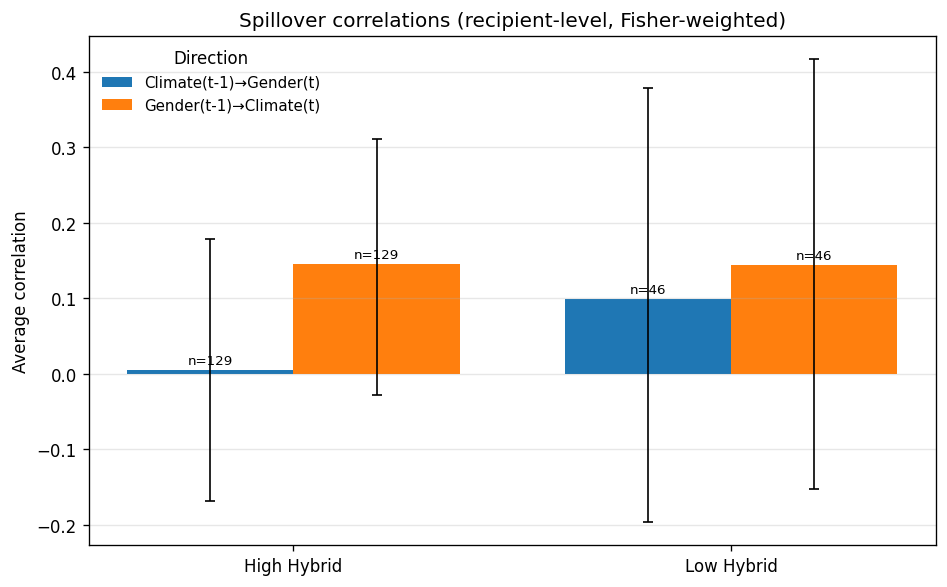

Saved: recipient_level_spillover_correlations.png


In [118]:
from scipy.stats import pearsonr, norm

df_agg = (
    combined
    .groupby(["RecipientName","Year"], as_index=False)
    .agg(
        year_gender  = ("usd_only_gender",  "sum"),
        year_climate = ("usd_only_climate", "sum"),
        year_hybrid  = ("usd_both_tags",    "sum")
    )
).sort_values(["RecipientName","Year"])

# Lags per recipient
df_agg["lag_gender"]  = df_agg.groupby("RecipientName")["year_gender"].shift(1)
df_agg["lag_climate"] = df_agg.groupby("RecipientName")["year_climate"].shift(1)

# Recipient-specific hybrid regime (above/below own median)
med = df_agg.groupby("RecipientName")["year_hybrid"].transform("median")
df_agg["Regime"] = np.where(df_agg["year_hybrid"] >= med, "High Hybrid", "Low Hybrid")

#Per-recipient correlations
def corr_with_n(d, x, y):
    s = d[[x,y]].dropna()
    n = len(s)
    if n >= 3 and s[x].std(ddof=1) > 0 and s[y].std(ddof=1) > 0:
        r, p = pearsonr(s[x], s[y])
    else:
        r, p, n = np.nan, np.nan, 0
    return r, n, p

rows = []
for (rec, regime), g in df_agg.groupby(["RecipientName","Regime"]):
    r_gc, n_gc, _ = corr_with_n(g, "lag_gender",  "year_climate")  # Gender(t-1)->Climate(t)
    r_cg, n_cg, _ = corr_with_n(g, "lag_climate", "year_gender")   # Climate(t-1)->Gender(t)
    rows += [
        {"RecipientName": rec, "Regime": regime, "direction": "Gender(t-1)→Climate(t)", "r": r_gc, "n": n_gc},
        {"RecipientName": rec, "Regime": regime, "direction": "Climate(t-1)→Gender(t)", "r": r_cg, "n": n_cg},
    ]

detail = pd.DataFrame(rows).dropna(subset=["r"])

#Fisher-z weighted average + 95% CI
def fisher_mean_ci(rs, ns, alpha=0.05):
    m = np.isfinite(rs) & np.isfinite(ns) & (ns >= 4)
    if not m.any():
        return np.nan, (np.nan, np.nan), 0
    z = np.arctanh(rs[m])
    w = (ns[m] - 3).astype(float)
    z_bar = np.sum(w * z) / np.sum(w)
    # analytic SE for pooled z: 1/sqrt(sum(n_i-3))
    se = 1.0 / np.sqrt(np.sum(w))
    zc = norm.ppf(1 - alpha/2)
    lo, hi = z_bar - zc*se, z_bar + zc*se
    return np.tanh(z_bar), (np.tanh(lo), np.tanh(hi)), int(np.sum(w) + 3)

summary_rows = []
for regime, g in detail.groupby("Regime"):
    for direction in ["Gender(t-1)→Climate(t)", "Climate(t-1)→Gender(t)"]:
        r_bar, (lo, hi), n_eff = fisher_mean_ci(
            g.loc[g["direction"]==direction, "r"].values,
            g.loc[g["direction"]==direction, "n"].values
        )
        summary_rows.append({"Regime": regime, "direction": direction,
                             "r_bar": r_bar, "ci_lo": lo, "ci_hi": hi, "n_eff": n_eff})
summary = pd.DataFrame(summary_rows).sort_values(["Regime","direction"])
print(summary)

# 4) Plot with error bars + n
plot = summary.pivot(index="Regime", columns="direction", values="r_bar")
ci_lo = summary.pivot(index="Regime", columns="direction", values="ci_lo")
ci_hi = summary.pivot(index="Regime", columns="direction", values="ci_hi")
n_eff = summary.pivot(index="Regime", columns="direction", values="n_eff")

fig, ax = plt.subplots(figsize=(8,5), dpi=120)
x = np.arange(len(plot.index))
width = 0.38
dirs = list(plot.columns)

for i, d in enumerate(dirs):
    vals = plot[d].values
    errs = np.vstack([vals - ci_lo[d].values, ci_hi[d].values - vals])
    ax.bar(x + (i-0.5)*width, vals, width, label=d)
    ax.errorbar(x + (i-0.5)*width, vals, yerr=errs, fmt='none', ecolor='k', capsize=3, lw=1)

    # annotate n_eff
    for j, regime in enumerate(plot.index):
        nn = n_eff.loc[regime, d]
        yv = vals[j]
        ax.text(x[j] + (i-0.5)*width, yv + 0.004, f"n={int(nn)}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot.index)
ax.set_ylabel("Average correlation")
ax.set_title("Spillover correlations (recipient-level, Fisher-weighted)")
ax.grid(axis='y', alpha=0.3)
ax.legend(title="Direction", fontsize=9, frameon=False)
plt.tight_layout()
out = "recipient_level_spillover_correlations.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

At the recipient level, last year’s gender funding tends to be a better predictor of this year’s climate funding than the reverse, notably when the recipient already has hybrid activity. However, the correlation bars’ confidence intervals still include zero due to limited sample and heterogeneity, so we rely on the fixed-effects model for a precise effect: +10% gender → ~+7% climate next year